 # Berechnung der Sicherheit vor Grundbruch bei Flächengründungen

 ## Interaktives Skript: Fundamentabmessungen, Bodenprofil, Grundbruch + Plots



 **Was macht dieses Notebook?**

 - Führt Schritt für Schritt durch die Eingaben (Fundamenttyp & -abmessungen, Bodenprofil inkl. GW, Lasten).

 - Ermittelt Bemessungssituation nach EC7 und berechnet **δ** (Lastneigungswinkel) sowie **Bemessungslasten**.

 - Zeichnet Grundriss & Seitenansicht mit **Nullpunkt unten links** und **unterbrochener GOK-Linie**.

 - Berechnet den **Grundbruchwiderstand** und gibt **alle Zwischenkennwerte** (N-Faktoren, Form-/Neigungsbeiwerte, γ1/γ2, q0, …) aus.

 - Bei **zweischichtigem Boden**: Zuerst **Iterationstabelle** anzeigen, dann erst Grundbruchnachweis starten.



 > Hinweis: Die Berechnungsfunktionen sind *unverändert* aus dem Skript übernommen. Dieses Notebook strukturiert nur die Bedienung und die Ausgaben.



 ### Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import numpy as np
from matplotlib.patches import Polygon  # für draw_right_failure_polygon
from tkinter import *


 ### Funktionsblöcke

In [ ]:
### Hilfsfunktionen
# Diese Funktionen helfen bei der Umrechnung von Grad in Radiant und umgekehrt.
def deg2rad(x): return np.deg2rad(x)     
def rad2deg(x): return np.rad2deg(x)     

# get_input() fragt den Benutzer nach einer Zahl. Es ersetzt eventuelle Kommas durch Punkte, sodass auch Dezimalzahlen korrekt erkannt werden.
def get_input(prompt):
    """Fragt den Benutzer nach einer Zahl und wandelt Kommas zu Punkten um."""
    while True:
        val = input(f"{prompt}: ").strip().replace(',', '.')
        try:
            return float(val)
        except ValueError:
            print("Ungueltige Eingabe - bitte eine Zahl eingeben.")

# get_design_situation() lässt den Benutzer eine von drei Bemessungssituationen wählen. 
# Je nach Auswahl werden verschiedene Sicherheitsbeiwerte (gamma_Werte) zurückgegeben.
def get_design_situation():
    """
    Fragt die EC7-Bemessungssituation ab (BS-P, BS-T oder BS-A/BS-E)
    und legt daraus die Teilbeiwerte fest:
      gamma_G   - fuer unguenstige permanente Lasten
      gamma_Q   - fuer unguenstige veraenderliche Lasten
      gamma_M   - fuer Bodenkennwerte (c', phi')
      gamma_phi   - fuer den Reibungsbeiwert tan phi'
      gamma_c   - fuer die Kohaesion c'
      gamma_R   - fuer den Widerstand R (optional, z.B. Erdbau- bzw. Grundbruchwiderstand)
    """
    print("\n--- Bemessungssituation auswaehlen ---")
    print(" 1) BS-P  (permanent)")
    print(" 2) BS-T  (transient)")
    print(" 3) BS-A/BS-E  (accidental / earthquake)")
    while True:
        choice = input("Auswahl [1/2/3]: ").strip()
        if choice in ("1","2","3"):
            break
    
    if choice == "1":
        bs = "BS-P"
        gamma_G   = 1.35   
        gamma_Q   = 1.50   
        gamma_M   = 1.00   
        gamma_phi = 1.00   
        gamma_c   = 1.00   
        gamma_R   = 1.40   
    elif choice == "2":
        bs = "BS-T"
        gamma_G   = 1.20
        gamma_Q   = 1.30
        gamma_M   = 1.00
        gamma_phi = 1.00
        gamma_c   = 1.00
        gamma_R   = 1.30
    else:
        bs = "BS-A/BS-E"
        gamma_G   = 1.10
        gamma_Q   = 1.10
        gamma_M   = 1.00
        gamma_phi = 1.00
        gamma_c   = 1.00
        gamma_R   = 1.20

    # Diese Ausgaben zeigen dem Benutzer die ausgewählte Situation und die zugehörigen Parameter.
    print(f"\nGewaehlte Situation: {bs}")
    print(f"--> gamma_G  = {gamma_G:.2f}   gamma_Q  = {gamma_Q:.2f}")
    print(f"--> gamma_M  = {gamma_M:.2f}   gamma_phi  = {gamma_phi:.2f}   gamma_c = {gamma_c:.2f}")
    print(f"--> gamma_R  = {gamma_R:.2f}\n")

    return bs, gamma_G, gamma_Q, gamma_M, gamma_phi, gamma_c, gamma_R

# ==========================================
# Fundamenttyp, Abmessungen und Bodenprofil
# Auswahl aus Streifen- oder Rechteckfundament
# ==========================================
# get_foundation_type() fragt, ob das Fundament als Rechteck (Einzelfundament) oder als Streifenfundament (pro lfm) berechnet werden soll.
def get_foundation_type():
    """Fragt den Typ des Fundaments ab: Rechteck oder Streifenfundament (Berechnung je lfm.)."""
    print("\n--- Fundamenttyp ---")
    print(" 1) Rechteck (Einzelfundament)")
    print(" 2) Streifenfundament (Berechnung je lfm; a = 1,00 m)")
    while True:
        c = input("Auswahl [1/2]: ").strip()
        if c in ("1", "2"):
            return "Rechteck" if c == "1" else "Streifen"
        print("Bitte 1 oder 2 eingeben.")
    
        # Ausgabe der aktuellen Fundamentart (falls vorhanden), sonst Funktion aufrufen
        if 'foundation_type' in globals():
            print(f"Fundamenttyp: {get_foundation_type}")
        else:
            ft = get_foundation_type()
            print(f"Fundamenttyp: {ft}")

# get_foundation_dimensions() fragt die Abmessungen des Fundaments ab. 
# Abhängig vom Fundamenttyp werden verschiedene Prüfungen durchgeführt.
def get_foundation_dimensions(foundation_type):
    """
    Fragt Abmessungen für das Fundament ab.
    Bei Streifenfundamenten ist die Länge (a) fix auf 1,00 m, während bei Rechteckfundamenten alle Maße abgefragt werden.
    Es wird sichergestellt, dass die Eingaben sinnvoll sind (z. B. h >= d oder a >= b).
    """
    while True:
        print("\n--- Fundamentabmessungen ---")
        # Streifenfundament
        if foundation_type == "Streifen":
            a = 1.00  # Länge je lfm fix
            b = get_input("Breite b (m)")
            if b <= 0:
                print(" b muss > 0 sein."); continue
            h = get_input("Hoehe h (m)")
            if h <= 0:
                print(" h muss > 0 sein."); continue
            d = get_input(f"Einbindetiefe d (m, <= h = {h:.3f})")
            if d <= 0 or d > h:
                print(f" d muss > 0 und <= h ({h:.3f}) sein."); continue
            
            # Ausgabe der gewählten Fundamentabmessungen
            print("\n--- Gewählte Fundamentabmessungen ---")
            print(f"Fundamenttyp: {foundation_type}")
            print(f"a = {a:.3f} m   b = {b:.3f} m   h = {h:.3f} m   d = {d:.3f} m")
            return a, b, h, d

        a = get_input("Laenge a (m)")
        if a <= 0:
            print(" a muss > 0 sein."); continue

        b = get_input(f"Breite b (m, <= a = {a:.3f})")
        if b <= 0 or b > a:
            print(f" b muss > 0 und <= a ({a:.3f}) sein."); continue

        h = get_input("Hoehe h (m)")
        if h <= 0:
            print(" h muss > 0 sein."); continue

        d = get_input(f"Einbindetiefe d (m, <= h = {h:.3f})")
        if d <= 0 or d > h:
            print(f" d muss > 0 und <= h ({h:.3f}) sein."); continue

        # Ausgabe der gewählten Fundamentabmessungen
        print("\n--- Gewählte Fundamentabmessungen ---")
        print(f"Fundamenttyp: {foundation_type}")
        print(f"a = {a:.3f} m   b = {b:.3f} m   h = {h:.3f} m   d = {d:.3f} m")

        return a, b, h, d

# get_soil_profile() fragt den Bodenaufbau ab. 
# Hier werden die Eigenschaften der Bodenschichten (wie Winkele, Wichte, Kohäsion) sowie ggf. Grundwasser abgefragt.
def get_soil_profile():
    """
    Fragt den Bodenaufbau ab (ein- oder zweischichtig).
    Es werden die Eigenschaften jeder Schicht abgefragt.
    Bei zwei Schichten wird zusätzlich die Tiefe der oberen Grenze der unteren Schicht angegeben.
    Falls Grundwasser vorhanden ist, wird dessen Tiefe abgefragt.
    """
    # Schichtanzahl
    while True:
        n = input("\nAnzahl der Bodenschichten (1 oder 2): ").strip()
        if n in ('1','2'):
            n = int(n); break
        print("Bitte 1 oder 2 eingeben.")

    layers = []
    for i in range(1, n+1):
        name  = input(f"Bezeichnung Schicht {i}: ").strip() or f"Schicht_{i}"
        phi   = get_input(f"Winkel phi Schicht {i} (degree)")
        gamma = get_input(f"Wichte gamma Schicht {i} (kN/m^3)")
        c     = get_input(f"Kohaesion c Schicht {i} (kN/m^2)")
        bottom = None
        # Bei zwei Schichten wird die Oberkante der unteren Schicht abgefragt.
        if n == 2 and i == 1:
            bottom = get_input("Tiefe UK Schicht 1 unter GOK (m)")
        layers.append({
            "name":   name,
            "phi":    phi,
            "gamma":  gamma,
            "c":      c,
            "bottom": bottom
        })

    # Grundwassereingabe
    gw = input("\nIst Grundwasser vorhanden? (j/n): ").strip().lower()
    if gw == 'j':
        z_gw    = get_input("Tiefe GW-Spiegel unter GOK (m)")
        gamma_w = 10.0
    else:
        z_gw    = None
        gamma_w = 0.0

    # Berechnet die Wichte unter Auftrieb (gamma_prime), falls Grundwasser in einer Schicht vorhanden ist.
    for idx, layer in enumerate(layers):
        top       = 0.0 if idx == 0 else layers[idx-1]["bottom"]
        bottom_fl = layer["bottom"] or float('inf')

        if z_gw is None or z_gw >= bottom_fl:
            layer["gamma_prime"] = layer["gamma"]
        else:
            layer["gamma_prime"] = layer["gamma"] - gamma_w

    # Ausgabe des eingegebenen Bodenaufbaus mit Kennwerten je Schicht
    print("\n-----Bodenaufbau-----")
    print("\nEingegebener Bodenaufbau:")
    print("-" * 86)
    hdr = f"{'Idx':>3} {'Bezeichnung':<14} {'phi (deg)':>10} {'gamma (kN/m³)':>16} {'c (kN/m²)':>12} {'gamma\' (kN/m³)':>18} {'UK (m)':>8}"
    print(hdr)
    print("-" * 86)
    for i, L in enumerate(layers, start=1):
        name = str(L.get("name", f"Schicht_{i}"))
        phi = float(L.get("phi", 0.0))
        gamma = float(L.get("gamma", 0.0))
        c = float(L.get("c", 0.0))
        gamma_p = float(L.get("gamma_prime", gamma))
        bottom = L.get("bottom")
        bottom_str = "-" if bottom is None else f"{float(bottom):.3f}"
        print(f"{i:3d} {name:<14} {phi:10.3f} {gamma:16.3f} {c:12.3f} {gamma_p:18.3f} {bottom_str:>8}")
    print("-" * 86)
    # Grundwasserinfo
    if z_gw is not None:
        print(f"Grundwasser: vorhanden, GW-Spiegel = {z_gw:.3f} m unter GOK, gamma_w = {gamma_w:.3f} kN/m³")
    else:
        print("Grundwasser: nicht vorhanden")

    return layers, z_gw, gamma_w

# get_loads() fragt die charakteristischen Lasten ab. 
# Es werden sowohl vertikale als auch horizontale Lasten abgefragt, abhängig vom Fundamenttyp.
def get_loads(foundation_type="Rechteck"):
    """
    Fragt die Lasten am Fundament ab.
    Rückgabe: charakteristische Lasten für ständige, veränderliche (vertikale) und horizontale Lasten.
    Die Einheit hängt vom Fundamenttyp ab.
    """
    unit = "kN/m" if foundation_type == "Streifen" else "kN"
    print("\n--- Lasten am Fundament ---")
    # Vertikale Lastabfrage
    Vgk = get_input(f"Charakteristische staendige Last Vg,k  ({unit})")
    var = input(f"Tritt eine vertikale veraenderliche Last auf? (j/n): ").strip().lower()
    Qk  = get_input(f"Charakteristische vertikale veraenderliche Last Qk ({unit})") if var == 'j' else 0.0

    # Horizontale Lastabfrage
    varH = input(f"Tritt eine horizontale Last auf? (j/n): ").strip().lower()
    Hk   = get_input(f"Charakteristische horizontale Last Hk ({unit})") if varH == 'j' else 0.0

    # Ausgabe der gewählten Lasten
    print("\n--- Gewählte Lasten (charakteristisch) ---")
    print(f"Vg,k = {Vgk:.3f} {unit}")
    print(f"Qk   = {Qk:.3f} {unit}" if Qk and abs(Qk) > 1e-12 else "Qk   = 0.000 " + unit)
    print(f"Hk   = {Hk:.3f} {unit}" if Hk and abs(Hk) > 1e-12 else "Hk   = 0.000 " + unit)

    return Vgk, Qk, Hk, unit

# effective_dimensions_from_eccentricity() berechnet reduzierte Fundamentmaße, falls Lasten exzentrisch aufgebracht werden.
def effective_dimensions_from_eccentricity(a: float, b: float, e_a: float = 0.0, e_b: float = 0.0):
    """
    Berechnet die effektiven Abmessungen (a' und b') des Fundaments, wenn Lasten exzentrisch wirken.
    Formel: a' = a - 2·|e_a|, b' = b - 2·|e_b|
    """
    ea = abs(float(e_a))
    eb = abs(float(e_b))
    a_p = max(0.0, float(a) - 2.0 * ea)
    b_p = max(0.0, float(b) - 2.0 * eb)

    return a_p, b_p, ea, eb

def _clamp(x, a, b): 
    return max(a, min(b, x))

def angles_with_delta_general(phi_deg: float, delta_deg: float,
                              alpha_deg: float = 0.0, beta_deg: float = 0.0):

    tol = 1e-9
    # --- Sonderfall φ≈0: θ1=θ2=θ3=45° ---
    if abs(phi_deg) <= tol:
        return {
            "theta1": 45.0, "theta2": 45.0, "theta3": 45.0,
            "eps1": 0.0, "eps2": 0.0, "nu": 90.0,
            "alpha": alpha_deg, "beta": beta_deg, "delta": delta_deg
        }

    # --- |δ| < φ; wenn verletzt → Grundfall (δ=0) ---
    if abs(delta_deg) >= abs(phi_deg) - tol:
        th1 = 45.0 - 0.5*phi_deg
        th2 = 45.0 + 0.5*phi_deg
        return {
            "theta1": th1, "theta2": th2, "theta3": th2,
            "eps1": 0.0, "eps2": 0.0, "nu": 90.0,
            "alpha": alpha_deg, "beta": beta_deg, "delta": delta_deg
        }

    # --- Allgemeiner Fall ---
    sphi = math.sin(deg2rad(phi_deg))
    eps1 = math.degrees(math.asin(max(-1.0, min(1.0, -math.sin(deg2rad(beta_deg))/sphi))))
    eps2 = math.degrees(math.asin(max(-1.0, min(1.0, -math.sin(deg2rad(delta_deg))/sphi))))

    theta1 = 45.0 - 0.5*phi_deg - 0.5*(eps1 + beta_deg)      # (A.1)
    theta2 = 45.0 + 0.5*phi_deg - 0.5*(eps2 - delta_deg)     # (A.3)
    theta3 = 45.0 + 0.5*phi_deg + 0.5*(eps2 - delta_deg)     # (A.4)
    nu     = 180.0 - alpha_deg - beta_deg - theta1 - theta2  # (A.6)

    return {"theta1": theta1, "theta2": theta2, "theta3": theta3,
            "eps1": eps1, "eps2": eps2, "nu": nu,
            "alpha": alpha_deg, "beta": beta_deg, "delta": delta_deg}


# active_rankine_geometry_with_delta() berechnet die Geometrie des aktiven Rankine-Keils, 
# wenn zusätzlich ein Delta-Winkel (δ) berücksichtigt wird. Dies ist relevant, wenn horizontale Lasten wirken.
def active_rankine_geometry_with_delta(b: float, d: float, phi_deg: float, delta_deg: float,
                                       alpha_deg: float = 0.0, beta_deg: float = 0.0):
    """
    Aktiver Keil für δ≠0: Apex = Schnitt der Geraden (b,-d) mit Steigung tanθ2 und (0,-d) mit Steigung -tanθ3.
    """
    ang = angles_with_delta_general(phi_deg, delta_deg, alpha_deg, beta_deg)
    m_right = math.tan(deg2rad(ang["theta2"]))   
    m_left  = -math.tan(deg2rad(ang["theta3"]))  
    denom = (m_right - m_left)
    if abs(denom) < 1e-12:
        # Fallback auf symmetrischen Grundfall
        return active_rankine_geometry(b=b, d=d, phi_deg=phi_deg) | {"angles": ang}
    xA = (m_right * b) / denom
    yA = m_left * xA - d
    return {
        "theta2_deg": ang["theta2"], "theta3_deg": ang["theta3"], "angles": ang,
        "apex": (float(xA), float(yA)),
        "right_line": {"m": m_right, "c": -d - m_right*b, "p0": (b, -d), "p1": (float(xA), float(yA))},
        "left_line":  {"m": m_left,  "c": -d,              "p0": (0.0, -d), "p1": (float(xA), float(yA))},
        "special_phi0": (abs(phi_deg) < 1e-12)
    }

# log_spiral_from_apex_general() berechnet die Punkte einer logarithmischen Spirale, 
# die von der Keilspitze A zu einem bestimmten Punkt S führt. Diese Funktion wird verwendet, um die Spirale für den Rankine-Keil zu zeichnen.
def log_spiral_from_apex_general(apex_xy: tuple, pole_xy: tuple,
                                 phi_deg: float, v_deg: float, n_pts: int = 600):
    """
    Log-Spirale A→S um Pol 'pole_xy' mit Öffnungswinkel ν (Grad).
    (A.8) & (A.17) werden in der Diskretisierung abgebildet.
    """
    x0, y0 = pole_xy
    ax, ay = apex_xy
    r2 = math.hypot(ax - x0, ay - y0)
    thetaA_deg = math.degrees(math.atan2(ay - y0, ax - x0))
    if abs(phi_deg) < 1e-12:
        r1 = r2
        l_s = r2 * deg2rad(v_deg)
        nu_bar = np.linspace(0.0, v_deg, n_pts)
        thetas_deg = thetaA_deg + nu_bar
        rs = np.full_like(nu_bar, r2, dtype=float)
    else:
        r1 = r2 * math.exp(deg2rad(v_deg) * math.tan(deg2rad(phi_deg)))  
        l_s = (r1 - r2) / math.sin(deg2rad(phi_deg))                    
        nu_bar = np.linspace(0.0, v_deg, n_pts)
        thetas_deg = thetaA_deg + nu_bar
        rs = r2 * np.exp(deg2rad(nu_bar) * math.tan(deg2rad(phi_deg)))
    xs = x0 + rs * np.cos(deg2rad(thetas_deg))
    ys = y0 + rs * np.sin(deg2rad(thetas_deg))
    return {"apex": (float(ax), float(ay)), "pole": (float(x0), float(y0)),
            "thetaA_deg": float(thetaA_deg), "r2": float(r2), "r1": float(r1), "l_s": float(l_s),
            "thetas_deg": thetas_deg, "rs": rs, "xs": xs, "ys": ys,
            "xs_end": float(xs[-1]), "ys_end": float(ys[-1]), "v_deg": float(v_deg),
            "special_phi0": abs(phi_deg) < 1e-12}

# passive_rankine_right_from_spiral_end_theta() bestimmt die Geometrie des passiven Schenkels,
# wenn der Endpunkt der Spirale S und der Winkel θ1 gegeben sind.
def passive_rankine_right_from_spiral_end_theta(spi: dict, d: float, theta1_deg: float):
    """Passiver Schenkel für allgemeinen Fall: Gerade mit Steigung tanθ1 von S bis y=-d."""
    xs_end = float(spi["xs_end"]); ys_end = float(spi["ys_end"])
    m_p = math.tan(deg2rad(theta1_deg))
    x_end = xs_end + (-d - ys_end)/m_p if abs(m_p) > 1e-12 else xs_end
    return {"theta1_deg": theta1_deg, "m_p": m_p,
            "xs_end": xs_end, "ys_end": ys_end,
            "x_end": float(x_end), "y_end": -d,
            "L_seg": math.hypot(x_end - xs_end, (-d) - ys_end)}

# active_rankine_geometry(b, d, phi_deg) berechnet die Geometrie des aktiven Rankine-Keils im Grundfall (ohne δ).
# Es wird angenommen, dass der Winkel φ positiv ist und die Standardwerte für die Berechnungen verwendet werden.
def active_rankine_geometry(b: float, d: float, phi_deg: float):
    """
    Aktiver Rankine-Keil im Grundfall (ohne Berücksichtigung von δ):
    Berechnet die Geometrie des aktiven Keils (Apex, Flanken) für gegebene Fundamentabmessungen und den Reibungswinkel φ.
    """
    alpha_deg = 45.0 + 0.5 * phi_deg   
    theta2_deg = alpha_deg               
    theta3_deg = alpha_deg               

    # Keilspitze
    apex_x = b / 2.0
    apex_y = -d - (b / 2.0) * math.tan(deg2rad(alpha_deg))

    # Geraden
    m_right =  math.tan(deg2rad(alpha_deg))
    c_right = -d - m_right * b
    m_left  = -math.tan(deg2rad(alpha_deg))
    c_left  = -d

    special = abs(phi_deg) < 1e-12  # Sonderfall phi= 0

    return {
        "alpha_deg": alpha_deg,
        "theta2_deg": theta2_deg,
        "theta3_deg": theta3_deg,
        "apex": (apex_x, apex_y),
        "right_line": {"m": m_right, "c": c_right, "p0": (b, -d), "p1": (apex_x, apex_y)},
        "left_line":  {"m": m_left,  "c": c_left,  "p0": (0.0, -d), "p1": (apex_x, apex_y)},
        "special_phi0": special
    }

# draw_active_rankine(ax, geom) zeichnet den aktiven Rankine-Keil in ein gegebenes Matplotlib-Achsenobjekt ax.
# Es werden sowohl die rechte als auch die linke Flanke des Keils gezeichnet.
def draw_active_rankine(ax, geom, color='tab:orange', lw=2.0):
    """
    Zeichnet NUR den aktiven Keil (beide Flanken) und markiert die Keilspitze.
    Fuer deine einseitige Betrachtung kannst du auch nur 'right_line' verwenden.
    """
    # rechte Flanke (theta2)
    x0, y0 = geom["right_line"]["p0"]
    x1, y1 = geom["right_line"]["p1"]
    ax.plot([x0, x1], [y0, y1], color=color, lw=lw, zorder=6, label="Rankine aktiv (rechts, theta2)")

    # linke Flanke (theta3) - optional
    x0, y0 = geom["left_line"]["p0"]
    x1, y1 = geom["left_line"]["p1"]
    ax.plot([x0, x1], [y0, y1], color=color, lw=lw, zorder=6, linestyle='-.')

    # Keilspitze
    ax.plot(*geom["apex"], marker='o', color=color, zorder=7)

# log_spiral_right_from_apex(b, d, phi_deg, n_pts) berechnet die Punkte einer logarithmischen Spirale,
# die an der Keilspitze A beginnt und zu einem Punkt S führt. Diese Funktion wird verwendet, um die Spirale für den Rankine-Keil zu zeichnen.
def log_spiral_right_from_apex(b: float, d: float, phi_deg: float, n_pts: int = 600):
    """
    Berechnet die Punkte einer logarithmischen Spirale, die von der Keilspitze A zu einem Punkt S führt.
    Die Spirale wird für die Berechnung des aktiven Keils nach Rankine verwendet.
    """
    alpha_deg = 45.0 + 0.5 * phi_deg  
    v_deg     = 90.0

    # Keilspitze A
    apex_x = b / 2.0
    apex_y = -d - (b / 2.0) * math.tan(deg2rad(alpha_deg))

    # Pol
    x0, y0 = b, -d

   
    dx, dy = apex_x - x0, apex_y - y0
    r2 = math.hypot(dx, dy)               
    
    thetaA_deg = math.degrees(math.atan2(dy, dx))

    
    if abs(phi_deg) < 1e-12:
        r1 = r2
        l_s = r2 * math.pi / 2.0
        nu_bar = np.linspace(0.0, v_deg, n_pts)
        thetas_deg = thetaA_deg + nu_bar                            
        rs = np.full_like(nu_bar, r2, dtype=float) # r2 → r1

    else:
        r1 = r2 * math.exp(deg2rad(v_deg) * math.tan(deg2rad(phi_deg)))
        l_s = (r1 - r2) / math.sin(deg2rad(phi_deg))
        nu_bar = np.linspace(0.0, v_deg, n_pts)
        thetas_deg = thetaA_deg + nu_bar
        rs = r2 * np.exp(deg2rad(nu_bar) * np.tan(deg2rad(phi_deg)))

    # Kartesisch
    xs = x0 + rs * np.cos(deg2rad(thetas_deg))
    ys = y0 + rs * np.sin(deg2rad(thetas_deg))

    return {
        "alpha_deg": alpha_deg,
        "apex": (apex_x, apex_y),
        "pole": (x0, y0),
        "thetaA_deg": thetaA_deg,
        "r2": r2, "r1": r1, "l_s": l_s,
        "thetas_deg": thetas_deg, "rs": rs,
        "xs": xs, "ys": ys,
        "xs_end": float(xs[-1]), "ys_end": float(ys[-1]),
        "special_phi0": abs(phi_deg) < 1e-12
    }

# draw_log_spiral_right(ax, spi, color='crimson', lw=2.0) zeichnet die logarithmische Spirale,
# die für den aktiven Keil berechnet wurde, in das gegebene Matplotlib-Achsenobjekt ax.
def draw_log_spiral_right(ax, spi, color='crimson', lw=2.0):
    """Nur die rechte log. Spirale zeichnen - ohne Radien/Labels."""
    ax.plot(spi["xs"], spi["ys"], color=color, lw=lw, zorder=6)

# passive_rankine_right_from_spiral_end(spi, pr, b, d) bestimmt die Geometrie des passiven Rankine-Keils,
# der von einem Spiralenendpunkt S bis zur Sohle y=-d reicht.
def passive_rankine_right_from_spiral_end(spi: dict, d: float, phi_deg: float):
    """
    Passive Rankine-Gerade (rechte Seite) ab Spiralendpunkt S bis zur Sohle y=-d.
    """
    # Spiralendpunkt
    xs_end = float(spi["xs_end"])
    ys_end = float(spi["ys_end"])

    # theta1 nach Norm (Grundfall) und Steigung der Geraden
    theta1_deg = 45.0 - 0.5 * phi_deg   
    m_p = math.tan(deg2rad(theta1_deg))

    # Schnitt mit Sohle y = -d
    if abs(m_p) < 1e-12:
        
        x_end = xs_end
    else:
        x_end = xs_end + (-d - ys_end) / m_p
    y_end = -d

    
    if ys_end >= -d and abs(m_p) < 1e-12:
        
        L_seg = 0.0
    else:
        L_seg = math.hypot(x_end - xs_end, y_end - ys_end)

    return {
        "theta1_deg": theta1_deg,
        "m_p": m_p,
        "xs_end": xs_end, "ys_end": ys_end,   
        "x_end": x_end,   "y_end": y_end,    
        "L_seg": L_seg
    }

def draw_passive_rankine_right(ax, pr: dict, color='steelblue', lw=2.0, ls='--'):
    """Passive Rankine-Gerade (rechts) - ohne Beschriftung."""
    ax.plot([pr["xs_end"], pr["x_end"]],
            [pr["ys_end"], pr["y_end"]],
            color=color, lw=lw, ls=ls, zorder=6)
        
def right_failure_polygon(spi: dict, pr: dict, b: float, d: float):

    pts = []
    pts.append((b, -d))                       
    pts.append(tuple(spi["apex"]))            
    pts += list(zip(spi["xs"], spi["ys"]))    
    pts.append((pr["x_end"], -d))             
    
    return pts


def right_failure_polygon_including_active(act: dict, spi: dict, pr: dict, d: float):

    pts = []
    pts.append((0.0, -d))                       
    pts.append(tuple(act["apex"]))              
    pts += list(zip(spi["xs"], spi["ys"]))      
    pts.append((float(pr["x_end"]), -d))        
    return pts


def draw_right_failure_polygon(ax, pts,
                               facecolor='crimson', edgecolor='crimson',
                               alpha=0.22, lw=1.5):
    ax.add_patch(Polygon(pts, closed=True, facecolor=facecolor,
                         edgecolor=edgecolor, lw=lw, alpha=alpha, zorder=5))

def phi_at_base(layers, d):

    if len(layers) == 2 and d > (layers[0]['bottom'] or 0.0):
        return layers[1]['phi']
    return layers[0]['phi']

def zone_polygons_right(act: dict, spi: dict, pr: dict, b: float, d: float):

    A = tuple(act["apex"])
    F_right = (b, -d)
    F_left  = (0.0, -d)
    S       = (float(spi["xs_end"]), float(spi["ys_end"]))
    Xend    = (float(pr["x_end"]), -d)

    # 1) aktiver Keil (Dreieck)
    active_poly = [F_left, F_right, A]

    # 2) Prandtl-Zone: apex -> Spirale (A→S) -> (x_end,-d) -> (b,-d) -> apex
    prandtl_poly = [A]
    prandtl_poly += list(zip(spi["xs"], spi["ys"]))   # A → ... → S
    prandtl_poly += [Xend, F_right, A]

    # 3) passiver Keil: S -> (x_end,-d) -> (b,-d) -> S
    passive_poly = [S, Xend, F_right, S]

    return active_poly, prandtl_poly, passive_poly

def draw_zone(ax, poly, facecolor, edgecolor, alpha=0.25, lw=1.2, hatch=None, zorder=5):
    ax.add_patch(Polygon(poly, closed=True,
                         facecolor=facecolor, edgecolor=edgecolor,
                         lw=lw, alpha=alpha, hatch=hatch, zorder=zorder))

# --- HILFSFUNKTIONEN FÜR FLÄCHENBERECHNUNG ---

def polygon_area(pts):
    """Berechnet die Fläche eines Polygons"""
    if not pts or len(pts) < 3: 
        return 0.0
    x = [p[0] for p in pts]
    y = [p[1] for p in pts]
    s = 0.0
    for i in range(len(pts)):
        j = (i+1) % len(pts)
        s += x[i]*y[j] - x[j]*y[i]
    return abs(0.5*s)

def _intersect_hline(p1, p2, y_clip):
    
    x1, y1 = p1
    x2, y2 = p2
    
    if (y1 - y_clip) * (y2 - y_clip) > 1e-12:
        return None
    dy = y2 - y1
    if abs(dy) < 1e-12: 
        return None
    t = (y_clip - y1) / dy
    if t < -1e-9 or t > 1.0 + 1e-9: # Toleranz
        return None
    return (x1 + t*(x2-x1), y_clip)

def clip_polygon_y_ge(pts, y_clip):

    if not pts: return []
    out = []
    prev = pts[-1]
    prev_in = (prev[1] >= y_clip - 1e-9)
    
    for cur in pts:
        cur_in = (cur[1] >= y_clip - 1e-9)
        if prev_in and cur_in:
            out.append(cur)
        elif prev_in and not cur_in:
            P = _intersect_hline(prev, cur, y_clip)
            if P: out.append(P)
        elif not prev_in and cur_in:
            P = _intersect_hline(prev, cur, y_clip)
            if P: out.append(P)
            out.append(cur)
        prev = cur
        prev_in = cur_in
    return out

def spiral_wedge_polygon(spi, b, d):
    
    pts = [(b, -d)] # Pol
    pts.append(tuple(spi["apex"]))
    # Spiralepunkte hinzufügen
    pts += list(zip(spi["xs"], spi["ys"]))
    pts.append((b, -d)) # Schließen
    return pts

def active_triangle_polygon(act, b, d):
    
    A = tuple(act["apex"])
    return [(0.0, -d), (b, -d), A]

def passive_triangle_polygon(spi, pr, b, d):
    
    S  = (float(spi["xs_end"]), float(spi["ys_end"]))
    Xe = (float(pr["x_end"]), -d)
    return [S, Xe, (b, -d)]

# --- Schnitt Segment–horizontale Linie y = y_h ---
def segment_intersection_with_hline(x1, y1, x2, y2, y_h, tol=1e-9):

    if (y1 - y_h) * (y2 - y_h) > 0:
        return False, (None, None)
    if abs(y2 - y1) < tol:

        return False, (None, None)
    t = (y_h - y1) / (y2 - y1)  # 0..1
    if t < -tol or t > 1 + tol:
        return False, (None, None)
    x_star = x1 + t * (x2 - x1)
    return True, (float(x_star), float(y_h))

def spiral_intersection_with_hline(xs, ys, y_h, tol=1e-9):
    """
    Sucht den ersten Schnitt der polylinienartig diskretisierten Spirale mit y=y_h.
    Linear zwischen aufeinanderfolgenden Punkten interpoliert.
    Gibt (intersects, (x*,y_h), index) zurück.
    """
    xs = np.asarray(xs, dtype=float); ys = np.asarray(ys, dtype=float)
    s = ys - y_h
    for i in range(1, len(xs)):
        if s[i-1] * s[i] <= 0:  # Wechsel der Vorzeichen oder Endpunktschnitt
            ok, p = segment_intersection_with_hline(xs[i-1], ys[i-1], xs[i], ys[i], y_h, tol=tol)
            if ok:
                return True, p, i
    return False, (None, None), None

def detect_zsw_crossings(act: dict, spi: dict, pr: dict, z_sw: float, b: float, d: float):

    y_h = -float(z_sw)

    # 1) aktiver rechter Keil: (b,-d) -> Apex
    (x1, y1) = (b, -d)
    (x2, y2) = tuple(act["apex"])
    i_act, p_act = segment_intersection_with_hline(x1, y1, x2, y2, y_h)

    # 2) Spirale: A -> S (diskret)
    i_spi, p_spi, idx = spiral_intersection_with_hline(spi["xs"], spi["ys"], y_h)

    # 3) passiver Teil: S -> (x_end, -d)
    (xs_end, ys_end) = (float(spi["xs_end"]), float(spi["ys_end"]))
    (xe, ye) = (float(pr["x_end"]), -d)
    i_pas, p_pas = segment_intersection_with_hline(xs_end, ys_end, xe, ye, y_h)

    return {
        "active":  {"intersects": bool(i_act), "pt": p_act},
        "spiral":  {"intersects": bool(i_spi), "pt": p_spi},
        "passive": {"intersects": bool(i_pas), "pt": p_pas},
        "y_h": y_h
    }
def seg_len(P, Q):
    return math.hypot(Q[0]-P[0], Q[1]-P[1])

def split_segment_by_hline(P, Q, y_h, tol=1e-9):
    """
    Splittet die Länge des Segments P->Q an der Horizontalen y=y_h.
    Rückgabe: (L_oben, L_unten, Schnittpunkt oder None)
      'oben' = Teil mit y >= y_h (geringere Tiefe), 'unten' = y < y_h.
    """
    x1, y1 = P; x2, y2 = Q
    L_tot = seg_len(P, Q)

    if (y1 - y_h) * (y2 - y_h) < 0:
        t = (y_h - y1) / (y2 - y1)  
        xk = x1 + t * (x2 - x1); yk = y_h
        K = (float(xk), float(yk))
        L1 = seg_len(P, K); L2 = seg_len(K, Q)
        if y1 >= y_h:  
            return L1, L2, K
        else:           
            return L2, L1, K
    if y1 >= y_h and y2 >= y_h:
        return L_tot, 0.0, None
    else:
        return 0.0, L_tot, None

def outer_lengths_norm_zsw_GOK(phi_deg: float, r1: float, r2: float, zsw_gok: float | None, d: float):

    if zsw_gok is None:
        return dict(L1=0.0, L2=0.0, L3=0.0, L4=0.0, z_a=None, z_b=None, zsw_gok=None)

    th1 = 45.0 - 0.5*phi_deg
    th2 = th3 = 45.0 + 0.5*phi_deg
    s = lambda ang: math.sin(math.radians(ang))

    z_a = r2 * s(th2)   
    z_b = r1 * s(th1)  

    thickness_layer1_below_footing = max(0.0, zsw_gok - d)


    L1 = abs(thickness_layer1_below_footing / s(th2))

    L4 = abs(thickness_layer1_below_footing / s(th1))
    

    if thickness_layer1_below_footing >= z_a:
         L1 = abs(z_a / s(th2)) 
         L2 = 0.0
    else:
         L2 = abs((z_a - thickness_layer1_below_footing) / s(th2))


    if thickness_layer1_below_footing >= z_b:
         L4 = abs(z_b / s(th1))
         L3 = 0.0
    else:
         L3 = abs((z_b - thickness_layer1_below_footing) / s(th1))

    return dict(L1=L1, L2=L2, L3=L3, L4=L4, z_a=z_a, z_b=z_b, zsw_gok=float(zsw_gok))

# =======================
# Geometrie für Mittelung
# =======================

def get_zsw(layers):
    """Tiefe der Schichtgrenze (UK Schicht 1) unter GOK; None bei 1-schichtig."""
    if len(layers) == 2 and layers[0].get("bottom") is not None:
        return float(layers[0]["bottom"])
    return None

def _seg_len(P, Q):
    return math.hypot(Q[0]-P[0], Q[1]-P[1])

def _split_segment_by_hline(P, Q, y_h):

    x1, y1 = P; x2, y2 = Q
    if (y1 - y_h) * (y2 - y_h) < 0.0:
        t = (y_h - y1) / (y2 - y1)
        K = (x1 + t*(x2-x1), y_h)
        L1 = _seg_len(P, K); L2 = _seg_len(K, Q)
        if y1 >= y_h:   # Start oben
            return L1, L2, K
        else:
            return L2, L1, K
    # kein Schnitt
    L = _seg_len(P, Q)
    if y1 >= y_h and y2 >= y_h:
        return L, 0.0, None
    else:
        return 0.0, L, None
    
def split_polyline_length_by_y(xs, ys, y_threshold):

    L_top = 0.0
    L_bot = 0.0
    
    # Sicherstellen, dass wir Listen oder Arrays haben
    if len(xs) != len(ys) or len(xs) < 2:
        return 0.0, 0.0

    for i in range(len(xs)-1):
        x1, y1 = float(xs[i]), float(ys[i])
        x2, y2 = float(xs[i+1]), float(ys[i+1])
        
        dL = math.hypot(x2-x1, y2-y1)
        
        # Fall A: Segment komplett oben
        if y1 >= y_threshold and y2 >= y_threshold:
            L_top += dL
        # Fall B: Segment komplett unten
        elif y1 < y_threshold and y2 < y_threshold:
            L_bot += dL
        # Fall C: Segment schneidet die Grenze
        else:
           
            if abs(y2 - y1) > 1e-9:
                t = (y_threshold - y1) / (y2 - y1)
                # Schnittpunkt Koordinaten
                x_cross = x1 + t * (x2 - x1)
                
                # Teillängen
                dL1 = math.hypot(x_cross - x1, y_threshold - y1)
                dL2 = dL - dL1 # Rest
                
                # Zuordnung je nach Startpunkt
                if y1 >= y_threshold: 
                    
                    L_top += dL1
                    L_bot += dL2
                else:
                    
                    L_bot += dL1
                    L_top += dL2
            else:
                
                L_top += dL

    return L_top, L_bot

def outer_lengths(act: dict, spi: dict, pr: dict, b: float, d: float, z_sw: float | None):

    A = tuple(act["apex"])
    P_left = (0.0, -d)
    S = (float(spi["xs_end"]), float(spi["ys_end"]))
    E = (float(pr["x_end"]), -d)

    Ls = float(spi["l_s"])  # Normformel – stabil

    if z_sw is None:
        return dict(L1=_seg_len(P_left, A), L2=0.0, Ls=Ls,
                    L3=_seg_len(S, E), L4=0.0,
                    K_act=None, K_pas=None, y_sw=None)

    y_h = -float(z_sw)
    L1, L2, K_act = _split_segment_by_hline(P_left, A, y_h)
    L4, L3, K_pas = _split_segment_by_hline(S, E, y_h)  # beachte: unten = L3
    return dict(L1=L1, L2=L2, Ls=Ls, L3=L3, L4=L4,
                K_act=K_act, K_pas=K_pas, y_sw=y_h)

def geometric_averaging_inputs(act: dict, spi: dict, pr: dict, b: float, d: float,
                               phi_deg: float, layers):
    """
    Stellt alle Geometrie-Kennwerte bereit, die wir später zum Mitteln von
    φ, c und γ/γ' brauchen.
    """
    # Winkel (Grundfall)
    theta1 = 45.0 - 0.5*phi_deg
    theta2 = 45.0 + 0.5*phi_deg
    theta3 = theta2
    nu     = 90.0

    # markante Punkte
    A = tuple(act["apex"])                    
    S = (float(spi["xs_end"]), float(spi["ys_end"]))  
    E = (float(pr["x_end"]), -d)              

    z_a = (-d) - A[1]   
    z_b = (-d) - S[1]  

    r2 = float(spi["r2"])
    r1 = float(spi["r1"])
    Ls = float(spi["l_s"])


    z_sw = get_zsw(layers)
    lens = outer_lengths(act, spi, pr, b, d, z_sw)


    L_act_h = abs(A[0] - 0.0)
    L_pas_h = abs(E[0] - S[0])

    return {
        "theta1": theta1, "theta2": theta2, "theta3": theta3, "nu": nu,
        "A": A, "S": S, "E": E,
        "z_a": z_a, "z_b": z_b,
        "r1": r1, "r2": r2, "L_s": Ls,
        "L1": lens["L1"], "L2": lens["L2"], "L3": lens["L3"], "L4": lens["L4"],
        "L_total": lens["L1"]+lens["L2"]+Ls+lens["L3"]+lens["L4"],
        "z_sw": z_sw, "y_sw": lens["y_sw"],
        "K_act": lens["K_act"], "K_pas": lens["K_pas"],
        "L_act_h": L_act_h, "L_pas_h": L_pas_h
    }

def compute_failure_geometry(b: float, d: float, layers, phi_geom: float | None = None, n_pts:int=600):
    """
    Baut den Bruchkörper im Grundfall (α=β=δ=0) mit φ der OBEREN Schicht auf
    und liefert Geometrie + Längen zurück.
    """
    # φ für die Konstruktion: obere Schicht
    if phi_geom is None:
        phi_geom = float(layers[0]['phi'])

    # 1) aktiver Keil (Apex A)
    act = active_rankine_geometry(b=b, d=d, phi_deg=phi_geom)
    A = tuple(act["apex"])

    # 2) Prandtl-Spirale (rechts), Start im Apex, Pol (b,-d)
    spi = log_spiral_right_from_apex(b=b, d=d, phi_deg=phi_geom, n_pts=n_pts)
    S = (float(spi["xs_end"]), float(spi["ys_end"]))  # Übergangspunkt S

    # 3) passive Rankine-Gerade ab S bis auf die Sohle (y=-d)
    pr  = passive_rankine_right_from_spiral_end(spi, d=d, phi_deg=phi_geom)
    E   = (float(pr["x_end"]), -d)

    # 4) Schichtgrenze (UK Schicht 1) → Tiefe unter GOK
    z_sw_gok = get_zsw(layers)  # None oder float

    # 5)Längen nach Formeln 
    r1 = float(spi["r1"])
    r2 = float(spi["r2"])
    Ls = float(spi["l_s"])
    
    norm = outer_lengths_norm_zsw_GOK(phi_deg=phi_geom, r1=r1, r2=r2, 
                                      zsw_gok=z_sw_gok, d=d)

    # 6) (Optional) segmentbasierte Split-Längen für Plot/Debug

    split = outer_lengths(act, spi, pr, b=b, d=d, z_sw=z_sw_gok)

    # Paket
    geo = {
        "phi_geom": phi_geom,
        "act": act, "spi": spi, "pr": pr,
        "A": A, "S": S, "E": E,
        "r1": r1, "r2": r2, "L_s": Ls,

        
        "z_a": norm["z_a"], "z_b": norm["z_b"],
        "z_sw": z_sw_gok,                   # unter GOK
        "L1": norm["L1"], "L2": norm["L2"],
        "L3": norm["L3"], "L4": norm["L4"],
        "L_total": norm["L1"] + norm["L2"] + Ls + norm["L3"] + norm["L4"],
    }
    return geo

def _norm_lengths_from_geo(phi_deg: float, r1: float, r2: float, Ls: float, zsw_gok: float | None):
    """
    Berechnet L1..L4 nach deinen Grad-Formeln aus r1,r2, Ls und z_sw (unter GOK).
    Gibt auch z_a= r2*sin(theta2) und z_b= r1*sin(theta1) zurück.
    """
    if zsw_gok is None:
        return dict(L1=0.0, L2=0.0, L3=0.0, L4=0.0, L_s=float(Ls), z_a=0.0, z_b=0.0)

    th1 = 45.0 - 0.5*float(phi_deg)
    th2 = 45.0 + 0.5*float(phi_deg)   
    s = lambda ang: math.sin(math.radians(ang))

    z_a = float(r2) * s(th2)
    z_b = float(r1) * s(th1)

    L1 = abs(float(zsw_gok) / s(th2))               
    L2 = abs((float(zsw_gok) - z_a) / s(th2))       
    L4 = abs(float(zsw_gok) / s(th1))               
    L3 = abs((z_b - float(zsw_gok)) / s(th1))       

    return dict(L1=L1, L2=L2, L3=L3, L4=L4, L_s=float(Ls), z_a=z_a, z_b=z_b)

def _norm_areas_from_geo(phi_deg, r1, r2, z_a, z_b, b, l_h):

    if abs(phi_deg) < 1e-12:
        A_sp = 0.25 * math.pi * (r2**2)  
    else:
        A_sp = (r1**2 - r2**2) / (4.0 * math.tan(deg2rad(phi_deg)))
    A_act = 0.5 * z_a * b
    A_pas = 0.5 * z_b * max(l_h, 0.0)
    A_tot = A_sp + A_act + A_pas
    return A_sp, A_act, A_pas, A_tot

def iterate_equivalent_params_two_layer(b, d, layers,
                                        tol_rel=0.01, max_iter=50, verbose=True, n_pts=600):
    
    if len(layers) != 2:
        raise ValueError("Iteration ist nur für 2-schichtige Profile vorgesehen.")
        
    zsw_gok = float(layers[0]['bottom'])

    # 1. Check: Liegt Schichtgrenze unterhalb der Sohle?
    # Falls ja: Ganz normaler Iterations-Start
    # Falls nein (Grenze <= Sohle): Fall 1 Logik 
    if zsw_gok <= d + 1e-5:
        if verbose: print(f"Info: Schichtgrenze ({zsw_gok}m) <= Sohle ({d}m). Keine Iteration.")
        L2 = layers[1]
        
        phi_mean   = 0.5 * (float(layers[0]['phi']) + float(layers[1]['phi']))
        final_phi  = float(L2['phi'])
        delta_deg  = final_phi - phi_mean
        
        dummy_row = {
            "it": 0, "phi_geom": final_phi, "phi_avg": final_phi,
            "theta1": 45.0-0.5*final_phi, "theta2": 45.0+0.5*final_phi,
            "Ls": 0.0, "l_ges": 0.0,
            "A_sp": 0.0, "A_sp_top": 0.0, "A_act": 0.0, "A_act_top": 0.0,
            "A_pas": 0.0, "A_pas_top": 0.0, "A_tot": 0.0, "A_top": 0.0, "A_bot": 0.0,
            "gamma_avg": float(L2['gamma_prime']), "c_avg": float(L2['c']), "rel": 0.0,
            "L1": 0.0, "L2": 0.0, "L3": 0.0, "L4": 0.0
        }
        return {
            "phi_eq": final_phi,
            "gamma_eq": float(L2['gamma_prime']),
            "c_eq": float(L2['c']),
            "iterations": 0, 
            "rows": [dummy_row],
            "final_geo": compute_failure_geometry(b=b, d=d, layers=layers, phi_geom=final_phi, n_pts=n_pts),
            "phi_mean": phi_mean, "delta_deg": delta_deg, 
            "delta_abs": abs(delta_deg), "within_5deg": (abs(delta_deg) <= 5.0)
        }

    # Setup Iteration (Fall 2: Grenze > Sohle)
    phi1, phi2 = float(layers[0]['phi']), float(layers[1]['phi'])
    c1, c2     = float(layers[0]['c']), float(layers[1]['c'])
    gam1, gam2 = float(layers[0]['gamma_prime']), float(layers[1]['gamma_prime'])

    phi_geom = phi1 # Startwert mit oberer Schicht
    rows = []

    for it in range(1, max_iter+1):
        # A) Geometrie berechnen
        geo = compute_failure_geometry(b=b, d=d, layers=layers, phi_geom=phi_geom, n_pts=n_pts)
        
        # B) Längen holen
        L1, L2_len, L3, L4 = geo["L1"], geo["L2"], geo["L3"], geo["L4"]
        Ls_total = geo["L_s"]
        
        # Schichtgrenze
        Ls_top, Ls_bot = split_polyline_length_by_y(geo["spi"]["xs"], geo["spi"]["ys"], -zsw_gok)
        
        l_ges = L1 + L2_len + L3 + L4 + Ls_total
        
        L_top_sum = L1 + L4 + Ls_top

        L_bot_sum = L2_len + L3 + Ls_bot
        
        denom_len = max(l_ges, 1e-12)
        phi_avg = (phi1 * L_top_sum + phi2 * L_bot_sum) / denom_len
        c_avg   = (c1 * L_top_sum + c2 * L_bot_sum) / denom_len

        # C) FLÄCHEN für Gamma berechnen (ROBUST über Polygone)
        # Polygone erstellen
        act_poly = active_triangle_polygon(geo["act"], b, d)
        spi_poly = spiral_wedge_polygon(geo["spi"], b, d)
        pas_poly = passive_triangle_polygon(geo["spi"], geo["pr"], b, d)
        
        # 1. Gesamte Polygon-Flächen (statt analytisch, damit konsistent)
        A_act = polygon_area(act_poly)
        A_sp  = polygon_area(spi_poly)
        A_pas = polygon_area(pas_poly)
        A_tot = A_act + A_sp + A_pas

        # 2. Flächen im Boden 1
        y_clip = -zsw_gok
        A_act_top = polygon_area(clip_polygon_y_ge(act_poly, y_clip))
        A_spi_top = polygon_area(clip_polygon_y_ge(spi_poly, y_clip))
        A_pas_top = polygon_area(clip_polygon_y_ge(pas_poly, y_clip))
        A_top = A_act_top + A_spi_top + A_pas_top

        # 3. Restfläche Boden2
   
        A_bot = max(0.0, A_tot - A_top)

        # Gamma gewichtet nach FLÄCHE
        gamma_avg = (gam1 * A_top + gam2 * A_bot) / max(A_tot, 1e-12)

        rel = abs(phi_avg - phi_geom) / max(1e-9, abs(phi_geom))
        
        theta1 = 45.0 - 0.5 * phi_geom
        theta2 = 45.0 + 0.5 * phi_geom

        rows.append({
            "it": it, 
            "phi_geom": phi_geom, 
            "phi_avg": phi_avg, 
            "theta1": theta1, 
            "theta2": theta2,
            "Ls": Ls_total, 
            "l_ges": l_ges,
            "A_sp": A_sp, "A_sp_top": A_spi_top,
            "A_act": A_act, "A_act_top": A_act_top,
            "A_pas": A_pas, "A_pas_top": A_pas_top,
            "A_tot": A_tot, "A_top": A_top, "A_bot": A_bot,
            "gamma_avg": gamma_avg, 
            "c_avg": c_avg, 
            "rel": rel,
            "L1": L1, "L2": L2_len, "L3": L3, "L4": L4
        })
        
        if rel <= tol_rel:
            break
        phi_geom = phi_avg

    # D) 5°-BEDINGUNG
    limit_phi = min(phi1, phi2) + 5.0
    final_phi = phi_avg
    final_c   = c_avg
    
    if final_phi > limit_phi:
        if verbose:
            print(f"\n*** 5°-Bedingung aktiv! Reduziere phi von {final_phi:.2f}° auf {limit_phi:.2f}° ***")
        final_phi = limit_phi
        
        geo_final = compute_failure_geometry(b=b, d=d, layers=layers, phi_geom=final_phi, n_pts=n_pts)
        
        L1, L2_len, L3, L4 = geo_final["L1"], geo_final["L2"], geo_final["L3"], geo_final["L4"]
        Ls_total = geo_final["L_s"]
        
        Ls_top, Ls_bot = split_polyline_length_by_y(geo_final["spi"]["xs"], geo_final["spi"]["ys"], -zsw_gok)
        
        l_ges = L1 + L2_len + L3 + L4 + Ls_total
        L_top_sum = L1 + L4 + Ls_top
        L_bot_sum = L2_len + L3 + Ls_bot
        denom = max(l_ges, 1e-12)
        
        final_c = (c1 * L_top_sum + c2 * L_bot_sum) / denom
        
    phi_mean  = 0.5 * (phi1 + phi2)
    delta_deg = final_phi - phi_mean

    return {
        "phi_eq": final_phi,
        "gamma_eq": gamma_avg, 
        "c_eq": final_c,
        "iterations": rows[-1]["it"],
        "rows": rows,
        "final_geo": compute_failure_geometry(b=b, d=d, layers=layers, phi_geom=final_phi, n_pts=n_pts),
        "phi_mean": phi_mean,
        "delta_deg": delta_deg,
        "delta_abs": abs(delta_deg),
        "within_5deg": (abs(delta_deg) <= 5.0)
    }

    # --- 5°-Kriterium NACH der Iteration ---
    phi_mean  = 0.5 * (phi1 + phi2)
    delta_deg = rows[-1]["phi_avg"] - phi_mean
    delta_abs = abs(delta_deg)
    within_5deg = (delta_abs <= 5.0)

    return {
        "phi_eq": rows[-1]["phi_avg"],
        "gamma_eq": rows[-1]["gamma_avg"],
        "c_eq": rows[-1]["c_avg"],
        "iterations": rows[-1]["it"],
        "rows": rows,
        "final_geo": compute_failure_geometry(b=b, d=d, layers=layers,
                                              phi_geom=rows[-1]["phi_avg"], n_pts=n_pts),
        "phi_mean": phi_mean,
        "delta_deg": delta_deg,
        "delta_abs": delta_abs,
        "within_5deg": within_5deg
    }

def print_iteration_table(rows):
    """
    Iterationstabelle mit Einzelteilflächen + Top-Anteilen.
    Spalten:
      A_sp(A_sp^top)  A_act(A_act^top)  A_pas(A_pas^top)  |  A_tot  A_top  A_bot
    """
    hdr = ("it | φ_geom → φ_avg | θ1/θ2 | Ls  | l_ges | "
           "A_sp(A_top)  A_act(A_top)  A_pas(A_top) | A_tot  A_top  A_bot | γ_avg  c_avg | Δφ_rel")
    print("\n" + hdr)
    print("-"*len(hdr))
    for r in rows:
        print(f"{r['it']:>2d} | {r['phi_geom']:>6.3f} → {r['phi_avg']:>6.3f} | "
              f"{r['theta1']:>4.1f}/{r['theta2']:>4.1f} | "
              f"{r['Ls']:>4.2f} | {r['l_ges']:>5.2f} | "
              f"{r['A_sp']:>5.2f}({r['A_sp_top']:>5.2f})  "
              f"{r['A_act']:>5.2f}({r['A_act_top']:>5.2f})  "
              f"{r['A_pas']:>5.2f}({r['A_pas_top']:>5.2f}) | "
              f"{r['A_tot']:>5.2f} {r['A_top']:>5.2f} {r['A_bot']:>5.2f} | "
              f"{r['gamma_avg']:>6.2f} {r['c_avg']:>6.2f} | "
              f"{100*r['rel']:>5.2f}%")

def load_inclination_angle_delta_char(Vk: float, Hk: float) -> float:
    """
    Lastneigungswinkel δ (charakteristisch):
      tan δ = Hk / Vk  → δ = atan2(Hk, Vk)   [Grad]
    Vorzeichen folgt Hk (bei passiver Zone rechts: Hk>0 → δ>0).
    """
    if abs(Vk) < 1e-12:
        return 90.0 * (1.0 if Hk >= 0.0 else -1.0)
    return math.degrees(math.atan2(Hk, Vk))

def plan_exponent_m(a_eff: float, b_eff: float, omega_deg: float) -> float:
    """
    m = m_a cos^2(ω) + m_b sin^2(ω),
    m_a = (2 + a'/b') / (1 + a'/b'),  m_b = (2 + b'/a') / (1 + b'/a').
    ω = Winkel der T-Richtung gegenüber a' (Grad).
    """
    a_eff = float(max(a_eff, 1e-12))
    b_eff = float(max(b_eff, 1e-12))
    r_ab = a_eff / b_eff
    r_ba = b_eff / a_eff
    m_a = (2.0 + r_ab) / (1.0 + r_ab)
    m_b = (2.0 + r_ba) / (1.0 + r_ba)
    w = math.radians(omega_deg)
    return m_a * (math.cos(w)**2) + m_b * (math.sin(w)**2)

def inclination_factors_norm(phi_deg: float, c_k: float, Nd0: float,
                             delta_deg: float,
                             a_eff: float, b_eff: float, omega_deg: float,
                             T_char: float | None = None, A_eff: float | None = None):
    """
    Lastneigungsbeiwerte nach Tabelle 3 (Winkel in Grad).
    Fälle:
      φ>0:
         δ>0:  i_b=(1-tanδ)^(m+1),  i_d=(1-tanδ)^m,  i_c=(i_d*Nd0 - 1)/(Nd0-1)
         δ<0:  i_b = cosδ*(1-0.04·δ)^(0.64+0.028·φ),
                i_d = cosδ*(1-0.0244·δ)^(0.03+0.04·φ),
                i_c = (i_d*Nd0 - 1)/(Nd0-1)
      φ=0, c>0:
         i_d=1.0,  i_c = 0.5 + 0.5*sqrt( max(0, 1 - T/(A'·c)) ), i_b entfaellt.
    """
    phi_deg = float(phi_deg)
    delt = float(delta_deg)
    # Klammer gegen Divisionen
    def clamp01(x): return max(0.0, min(1.0, x))

    if phi_deg > 1e-9:
        if delt >= 0.0:
            m = plan_exponent_m(a_eff, b_eff, omega_deg)
            t = math.tan(math.radians(delt))
            ib = (1.0 - t)**(m + 1.0)
            id_ = (1.0 - t)**m
        else:
            cosd = math.cos(math.radians(delt))
            ib = cosd * (1.0 - 0.04  * delt)**(0.64 + 0.028*phi_deg)
            id_ = cosd * (1.0 - 0.0244* delt)**(0.03 + 0.04 *phi_deg)
        # i_c analog zu v_c:
        if Nd0 > 1.0:
            ic = (id_ * Nd0 - 1.0) / (Nd0 - 1.0)
        else:
            ic = id_ 
        return clamp01(ib), clamp01(id_), clamp01(ic)
    else:
        # φ = 0
        id_ = 1.0
        if (T_char is None) or (A_eff is None) or (c_k <= 0.0):
            ic = 1.0
        else:
            val = max(0.0, 1.0 - abs(T_char)/(A_eff * c_k))
            ic = 0.5 + 0.5 * math.sqrt(val)
        return 1.0, clamp01(id_), clamp01(ic)



# =============================================================================
# HILFSFUNKTIONEN GRUNDBRUCH
# =============================================================================

def base_factors(phi_deg):
    import math
    phi = math.radians(phi_deg)
    if abs(phi_deg) < 1e-12:
        Nd0, Nc0, Nb0 = 1.0, 5.14, 0.0
    else:
        Nd0 = (math.tan(math.pi/4 + phi/2)**2) * math.exp(math.pi*math.tan(phi))
        Nc0 = (Nd0 - 1.0) / math.tan(phi)
        Nb0 = (Nd0 - 1.0) * math.tan(phi)
    return Nb0, Nd0, Nc0

def layer_at_base(layers, d_):
    """
    Bestimmt die maßgebende Schicht an der Sohle.
    """
    if len(layers) == 2:
        bot = layers[0]['bottom']
        if bot is not None and d_ >= bot - 1e-9: 
            return layers[1]
    return layers[0]

def shape_rect(phi_deg, a_, b_, Nd0):
    import math
    r = b_/a_
    phi = math.radians(phi_deg)
    # DIN 4017 / EC7 Formbeiwerte
    vb = 1.0 - 0.3*r
    vd = 1.0 + r*math.sin(phi)
    vc = (vd*Nd0 - 1.0)/(Nd0 - 1.0) if abs(phi) > 1e-12 else 1.0 + 0.2*r
    return vb, vd, vc

def ground_slope(phi_deg, beta_deg_, Nd0):
    import math
    beta = math.radians(beta_deg_); phi = math.radians(phi_deg)
    if abs(phi) > 1e-12:
        lb = (1.0 - 0.5*math.tan(beta))**6
        ld = (1.0 - math.tan(beta))**1.9
        lc = (Nd0 * math.exp(-0.0349*beta_deg_*math.tan(phi)) - 1.0)/(Nd0 - 1.0)
    else:
        lb, ld, lc = 1.0, 1.0, 1.0 - 0.4*math.tan(beta)
    return lb, ld, lc

def base_slope(phi_deg, alpha_deg_):
    import math
    phi = math.radians(phi_deg)
    if abs(phi) > 1e-12:
        f = math.exp(-0.045*alpha_deg_*math.tan(phi))
        return f, f, f
    else:
        return 1.0, 1.0, 1.0 - 0.0068*alpha_deg_


# =============================================================================
# HAUPTFUNKTION GRUNDBRUCH
# =============================================================================

def compute_Rn_bearing(a, b, d, layers,
                       foundation_type="Rechteck",
                       gamma_R_v=1.0,
                       beta_deg=0.0, alpha_deg=0.0,
                       z_gw=None, gamma_w=0.0,
                       return_geometry: bool = True,
                       Hk_char: float | None = None,
                       Vk_char: float | None = None,
                       a_eff_for_shape: float | None = None,
                       b_eff_for_shape: float | None = None,
                       omega_deg: float = 0.0,
                       delta_char_deg: float | None = None,
                       q0_override: float | None = None):
    """
    Berechnet den Grundbruchwiderstand nach DIN 4017 / EC7.
    """
    import math

    # 1) Schicht an der Sohle ermitteln (für phi, c)

    base_layer = layer_at_base(layers, d)
    phi_k = float(base_layer['phi'])
    c_k   = float(base_layer['c'])

    # ---------- a′, b′ für Ansatz ----------
    a_p = 1.0 if foundation_type == "Streifen" else (a_eff_for_shape if a_eff_for_shape is not None else a)
    b_p = b_eff_for_shape if b_eff_for_shape is not None else b
    A_eff_shape = a_p * b_p

    # ---------- Grundwerte + Form/Gelände/Sohle ----------
    Nb0, Nd0, Nc0 = base_factors(phi_k)
    
    if foundation_type == "Streifen":
        vb = vd = vc = 1.0
    else:
        vb, vd, vc = shape_rect(phi_k, a_p, b_p, Nd0)
        
    lb, ld, lc = ground_slope(phi_k, beta_deg, Nd0)
    xb, xd, xc = base_slope(phi_k, alpha_deg)

    # ---------- Lastneigungs-Beiwerte i_* ----------
    def _clamp01(x): return max(0.0, min(1.0, x))
    
    if (Hk_char is not None) and (Vk_char is not None) and (abs(Hk_char) > 1e-12):
        delta_used_deg = (delta_char_deg if (delta_char_deg is not None) 
                          else math.degrees(math.atan2(Hk_char, Vk_char)))
        
        if phi_k > 1e-9:
            if delta_used_deg >= 0.0:
                r_ab = a_p / max(b_p, 1e-12)
                r_ba = b_p / max(a_p, 1e-12)
                m_a = (2.0 + r_ab) / (1.0 + r_ab)
                m_b = (2.0 + r_ba) / (1.0 + r_ba)
                w = math.radians(omega_deg)
                m = m_a*(math.cos(w)**2) + m_b*(math.sin(w)**2)
                t = math.tan(math.radians(delta_used_deg))
                ib = (1.0 - t)**(m + 1.0)
                id_ = (1.0 - t)**m
            else:
                cosd = math.cos(math.radians(delta_used_deg))
                ib = cosd * (1.0 - 0.04  * delta_used_deg)**(0.64 + 0.028*phi_k)
                id_ = cosd * (1.0 - 0.0244* delta_used_deg)**(0.03 + 0.04 *phi_k)
            ic = (id_ * Nd0 - 1.0)/(Nd0 - 1.0) if Nd0 > 1.0 else id_
        else:
            id_ = 1.0
            if (c_k > 0.0) and (A_eff_shape > 0.0):
                val = max(0.0, 1.0 - abs(Hk_char)/(A_eff_shape * c_k))
                ic = 0.5 + 0.5 * math.sqrt(val)
            else:
                ic = 1.0
            ib = 1.0
        ib = _clamp01(ib); id_ = _clamp01(id_); ic = _clamp01(ic)
    else:
        ib = id_ = ic = 1.0
        delta_used_deg = 0.0

    # ---------- Endgültige N_b, N_d, N_c ----------
    N_b = Nb0 * vb * ib * lb * xb
    N_d = Nd0 * vd * id_ * ld * xd
    N_c = Nc0 * vc * ic * lc * xc

    if q0_override is not None:
         q0 = q0_override
         gamma1 = q0 / max(d, 1e-6)
         # gamma2 berechnen wir aus den übergebenen 'layers' (Ersatz oder Original)
         _, _, gamma2 = overburden_with_gw(layers, d, z_gw, gamma_w)

    elif (z_gw is not None) and len(layers) == 1 and \
        (layers[0].get("name","").lower().startswith("ersatz") or layers[0].get("is_equiv", False)):
        gamma_eq = float(layers[0]["gamma"])
        q0, gamma1, gamma2 = overburden_with_gw_equiv_gamma(gamma_eq, d, z_gw, gamma_w)

    else:
        q0, gamma1, gamma2 = overburden_with_gw(layers, d, z_gw, gamma_w)

    # ---------- R_{n,k}, R_{n,d} ----------
    q_r_k = gamma2 * b_p * N_b + gamma1 * d * N_d + c_k * N_c
    R_n_k = a_p * b_p * q_r_k
    R_n_d = R_n_k / gamma_R_v

    # ---------- Details ----------
    details = {
        "a_p": a_p, "b_p": b_p, "A_eff_shape": A_eff_shape,
        "phi_k": phi_k, "c_k": c_k,
        "Nb0": Nb0, "Nd0": Nd0, "Nc0": Nc0,
        "N_b": N_b, "N_d": N_d, "N_c": N_c,
        "vb": vb, "vd": vd, "vc": vc,
        "lb": lb, "ld": ld, "lc": lc,
        "xb": xb, "xd": xd, "xc": xc,
        "i_b": ib, "i_d": id_, "i_c": ic,
        "delta_char_deg": delta_used_deg, "omega_deg": omega_deg,
        "gamma1": gamma1, "gamma2": gamma2, "q0": q0,
        "gamma_R_v": gamma_R_v,
    }

    if return_geometry:
        geom = compute_failure_geometry(b=b, d=d, layers=layers)
        details["geometry"] = geom

    return R_n_k, R_n_d, details

def overburden_with_gw(layers, d, z_gw, gamma_w):
    if d <= 0:
        top = layers[0]
        gamma2 = (top["gamma"] - gamma_w) if (z_gw is not None and d >= (z_gw or 0.0)) else top["gamma"]
        return 0.0, 0.0, gamma2

    q0 = 0.0
    z_top = 0.0
    gamma2 = None

    for idx, layer in enumerate(layers):
        z_bot = layer["bottom"] if layer["bottom"] is not None else float('inf')
        seg_top = z_top
        seg_bot = min(d, z_bot)
        if seg_bot > seg_top:
            if z_gw is None:
                q0 += layer["gamma"] * (seg_bot - seg_top)
            else:
                above_thk = max(0.0, min(seg_bot, z_gw) - seg_top)     # --> gamma
                below_thk = (seg_bot - seg_top) - above_thk           # --> gamma'
                if above_thk > 0: q0 += layer["gamma"] * above_thk
                if below_thk > 0: q0 += (layer["gamma"] - gamma_w) * below_thk

            if d <= seg_bot and gamma2 is None:
                if z_gw is not None and d >= z_gw:   # am/unter GW --> gamma'
                    gamma2 = layer["gamma"] - gamma_w
                else:
                    gamma2 = layer["gamma"]

        if d <= z_bot: break
        z_top = z_bot

    if gamma2 is None:
        last = layers[-1]
        gamma2 = (last["gamma"] - gamma_w) if (z_gw is not None and d >= z_gw) else last["gamma"]

    gamma1 = q0 / d
    return q0, gamma1, gamma2

def overburden_with_gw(layers, d, z_gw, gamma_w):
    if d <= 0:
        top = layers[0]
        gamma2 = (top["gamma"] - gamma_w) if (z_gw is not None and d >= (z_gw or 0.0)) else top["gamma"]
        return 0.0, 0.0, gamma2

    q0 = 0.0
    z_top = 0.0
    gamma2 = None

    for idx, layer in enumerate(layers):
        z_bot = layer["bottom"] if layer["bottom"] is not None else float('inf')
        seg_top = z_top
        seg_bot = min(d, z_bot)
        
        if seg_bot > seg_top:
            if z_gw is None:
                q0 += layer["gamma"] * (seg_bot - seg_top)
            else:
                above_thk = max(0.0, min(seg_bot, z_gw) - seg_top)
                below_thk = (seg_bot - seg_top) - above_thk
                if above_thk > 0: q0 += layer["gamma"] * above_thk
                if below_thk > 0: q0 += (layer["gamma"] - gamma_w) * below_thk

            if d <= z_bot + 1e-9 and gamma2 is None:
                is_boundary = abs(d - z_bot) < 1e-9
                if is_boundary and idx < len(layers) - 1:
                    pass 
                else:
                    if z_gw is not None and d >= z_gw:
                        gamma2 = layer["gamma"] - gamma_w
                    else:
                        gamma2 = layer["gamma"]

        if d <= z_bot: break
        z_top = z_bot

    if gamma2 is None:
        last = layers[-1]
        gamma2 = (last["gamma"] - gamma_w) if (z_gw is not None and d >= z_gw) else last["gamma"]

    gamma1 = q0 / d
    return q0, gamma1, gamma2

def plot_foundation(a, b, h, d, layers, z_gw, Vgk, Qk, foundation_type="Rechteck",
                    phi_geom_override: float | None = None,
                    Hk: float = 0.0,
                    a_eff: float | None = None, b_eff: float | None = None,
                    H_dir: str = "x",
                    delta_deg_for_geo: float | None = None,   
                    alpha_deg_geo: float = 0.0,
                    beta_deg_geo: float = 0.0):           

    """Grundriss unveraendert, Seitenansicht mit Boden, GOK, GW, Bodenkennwerten und Lastpfeil."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    fig.subplots_adjust(hspace=0.4)

    # --- 1) Grundriss ---
    rect1 = patches.Rectangle((0, 0), a, b,
                              facecolor='lightgray', edgecolor='black',
                              hatch='xx', zorder=2)
    ax1.add_patch(rect1)
    ax1.plot(0, 0, 'ko', zorder=3)
    ax1.annotate('', xy=(a, -0.02*b), xytext=(0, -0.02*b),
                 arrowprops=dict(arrowstyle='<->'))
    ax1.text(a/2, -0.05*b, 'a', ha='center', va='top')
    ax1.annotate('', xy=(-0.02*a, b), xytext=(-0.02*a, 0),
                 arrowprops=dict(arrowstyle='<->'))
    ax1.text(-0.05*a, b/2, 'b', rotation=90, ha='right', va='center')

    if (a_eff is not None) and (b_eff is not None) and (a_eff > 0.0) and (b_eff > 0.0):
        off_x = 0.5 * (a - a_eff)
        off_y = 0.5 * (b - b_eff)
        rect_eff = patches.Rectangle((off_x, off_y), a_eff, b_eff,
                                     facecolor='none', edgecolor='black',
                                     linestyle='--', linewidth=1.6, zorder=3)
        ax1.add_patch(rect_eff)
        ax1.text(off_x + a_eff/2, off_y + b_eff + 0.03*b, "a', b' (rechnerisch)",
                 ha='center', va='bottom', fontsize=9)

    if Hk and abs(Hk) > 1e-12:
        unit = "kN/m" if foundation_type == "Streifen" else "kN"
        cx, cy = a/2.0, b/2.0            # Fundamentmitte
        Lx = 0.35 * a                    # Pfeillänge in x-Richtung
        Ly = 0.35 * b                    # Pfeillänge in y-Richtung

        if H_dir.lower().startswith("y"):
            # T parallel zur kürzeren Seite b' (Pfeil zeigt nach +y)
            tail = (cx, cy - Ly)         # Start unterhalb der Mitte
            head = (cx, cy)              # Spitze genau in der Mitte
            ax1.annotate('', xy=head, xytext=tail,
                         arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=2.2))
            ax1.text(cx + 0.04*a, cy + 0.04*b, f"Hk = {Hk:.2f} {unit}",
                     ha='left', va='bottom', color='#2ca02c')
        else:
            # T parallel zur längeren Seite a' (Pfeil zeigt nach +x)
            tail = (cx - Lx, cy)         # Start links der Mitte
            head = (cx, cy)              # Spitze genau in der Mitte
            ax1.annotate('', xy=head, xytext=tail,
                         arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=2.2))
            ax1.text(cx, cy + 0.06*b, f"Hk = {Hk:.2f} {unit}",
                     ha='center', va='bottom', color='#2ca02c')


    ax1.set_aspect('equal','box')
    ax1.set_xlim(-0.1*a, 1.1*a)
    ax1.set_ylim(-0.1*b, 1.1*b)
    ax1.set_title('Grundriss')
    ax1.set_xlabel('Laenge (m)')
    ax1.set_ylabel('Breite (m)')

    # --- 2) Seitenansicht mit Bodenschichten ---
    y_bot = -d
    y_top = h - d

    # Gesamtdarstellungstiefe
    if len(layers) == 2:
        depth1  = layers[0]['bottom']
        bottom2 = depth1 + 8.0
    else:
        depth1  = None
        bottom2 = 8.0

    x_min= -0.8 * b
    x_max = 2.0 * b
    y_min = -bottom2
    # etwas mehr Platz oben: bisher y_max, jetzt +5
    y_max = max(0, y_top) + 0.2 * h + 5.0

    # Abstand vom linken Rand fuer Boden-Text
    x_text = x_min + 0.02 * (x_max - x_min)

    # --- φ an der Sohle (auch bei 2 Schichten) ---
    phi_base = phi_at_base(layers, d)

    # neu
    phi_geom = phi_geom_override if (phi_geom_override is not None) else phi

    # -----------------------------
    # Bodenschichten zeichnen (ohne Text!)
    # -----------------------------
    if len(layers) == 1:
        soil = patches.Rectangle((x_min, y_min),
                                 x_max - x_min,
                                 -y_min,
                                 facecolor='khaki', edgecolor='none', zorder=0)
        ax2.add_patch(soil)
       
        L = layers[0]
        text_single = (
            f"{L['name']}\n"
            f"phi = {L['phi']:.1f}degree\n"
            f"c = {L['c']:.2f} kN/m^2\n"
            f"gamma/gamma' = {L['gamma']:.2f}/{L['gamma_prime']:.2f} kN/m^3"
        )
    else:
        depth1  = layers[0]['bottom']
        bottom2 = depth1 + 8.0
        soil1 = patches.Rectangle((x_min, -depth1),
                                  x_max - x_min, depth1,
                                  facecolor='khaki', edgecolor='none', zorder=0)
        ax2.add_patch(soil1)
        soil2 = patches.Rectangle((x_min, -bottom2),
                                  x_max - x_min, bottom2 - depth1,
                                  facecolor='lightgreen', edgecolor='none', zorder=0)
        ax2.add_patch(soil2)

        L1 = layers[0]
        L2 = layers[1]
       
        text_top = (
            f"{L1['name']}\n"
            f"phi = {L1['phi']:.1f}degree\n"
            f"c = {L1['c']:.2f} kN/m^2\n"
            f"gamma/gamma' = {L1['gamma']:.2f}/{L1['gamma_prime']:.2f} kN/m^3"
        )
        text_bot = (
            f"{L2['name']}\n"
            f"phi = {L2['phi']:.1f}degree\n"
            f"c = {L2['c']:.2f} kN/m^2\n"
            f"gamma/gamma' = {L2['gamma']:.2f}/{L2['gamma_prime']:.2f} kN/m^3"
        )
    # - GOK-Linie bei y=0 -  
    ax2.hlines(0, x_min, x_max, colors='black', linewidth=1.5, zorder=2)
    ax2.text(x_max, 0, ' GOK', va='bottom', ha='left', color='black', zorder=2)

    # - Fundamentblock -  
    fund = patches.Rectangle((0, y_bot), b, h,
                             facecolor='lightgray', edgecolor='black',
                             hatch='xx', zorder=3)
    ax2.add_patch(fund)
    ax2.plot(0, y_bot, 'ko', zorder=4)

    # - GW-Linie (falls vorhanden) -  
    if z_gw is not None:
        y_gw = -z_gw
        ax2.hlines(y_gw, x_min, x_max,
                   colors='blue', linewidth=2, zorder=5)
        ax2.text(x_max, y_gw, ' GW', va='bottom', ha='left',
                 color='blue', zorder=5)

    # - Lastpfeil -  
    x_load         = b / 2
    # Pfeilspitze an der Fundament-Unterkante
    y_arrow_bottom = y_bot
    # Pfeilkopf deutlich unterhalb der Plot-Oberkante, z.B. 5 Einheiten ueber y_max-5
    y_arrow_top    = y_max - 0.5

    # Zeichne Pfeil von y_arrow_top nach y_arrow_bottom
    ax2.annotate(
        '',
        xy=(x_load, y_arrow_bottom),
        xytext=(x_load, y_arrow_top),
        arrowprops=dict(arrowstyle='->', color='red', lw=2),
        zorder=6
    )

    # Beschriftung rechts neben der Pfeilmitte
    mid_y_arrow = (y_arrow_top + y_arrow_bottom) / 2
    x_offset    = 0.02 * (x_max - x_min)
    unit = "kN/m" if foundation_type == "Streifen" else "kN"
    load_text = f"Vg,k = {Vgk:.2f} {unit}"
    if Qk > 0:
        load_text += f"\nQk = {Qk:.2f} {unit}"
    ax2.text(
        x_load + x_offset,
        mid_y_arrow,
        load_text,
        ha='left', va='center',
        color='red', zorder=6
    )
    # Beschriftung rechts neben dem Pfeil
    mid_y_arrow = (y_arrow_top + y_arrow_bottom) / 2
    x_offset    = 0.02 * (x_max - x_min)
    load_text = f"Vg,k = {Vgk:.2f} kN"
    if Qk > 0:
        load_text += f"\nQk = {Qk:.2f} kN"
    ax2.text(x_load + x_offset, mid_y_arrow, load_text,
             ha='left', va='center', color='red', zorder=6)
    
    # --- Horizontalpfeil links, auf Sohlhöhe, Spitze in Fundamentmitte ---
    if Hk and abs(Hk) > 1e-12:
        yH = -d
        x_tip   = b/2.0                 # Spitze in Mitte des Fundaments
        x_start = x_min + 0.03*(x_max-x_min)  # Start links im Plotbereich
        ax2.annotate('', xy=(x_tip, yH), xytext=(x_start, yH),
                     arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=2), zorder=6)
        # Beschriftung horizontal (links oberhalb des Pfeils)
        ax2.text(x_start-3, yH + 0.01*(y_max - y_min),
                 f"Hk = \n{Hk:.2f} {unit}", ha='left', va='bottom',
                 color='#2ca02c', zorder=6)

    # δ-Geometrie nur wenn:
    # - eine horizontale Last T vorhanden ist,
    # - der δ-Wert übergeben wurde,
    # - |δ| < φ (Voraussetzung der Norm),
    # - und die Richtung T in der b-Ebene liegt (H_dir == 'y');
    # andernfalls bleibt der Grundfall (α=β=δ=0).
    tol = 1e-9
    use_delta_ast = (
        (Hk is not None) and (abs(Hk) > 1e-12) and
        (delta_deg_for_geo is not None) and
        (phi_geom > tol) and
        (abs(delta_deg_for_geo) < phi_geom - tol)
    )

    if not use_delta_ast and (Hk is not None) and (abs(Hk) > 1e-12) and (delta_deg_for_geo is not None):
        print(f"⚠️ δ-Formeln nicht angewandt, weil |δ| ≥ φ (|δ|={abs(delta_deg_for_geo):.2f}°, φ={phi_geom:.2f}°). "
            "Gleitfläche bleibt im Grundfall.")


    if use_delta_ast:
        # allgemeiner Fall 
        act = active_rankine_geometry_with_delta(b=b, d=d, phi_deg=phi_geom,
                                                delta_deg=delta_deg_for_geo,
                                                alpha_deg=alpha_deg_geo, beta_deg=beta_deg_geo)
        draw_active_rankine(ax2, act)
        ang = act["angles"]
        spi = log_spiral_from_apex_general(apex_xy=act["apex"], pole_xy=(b, -d),
                                            phi_deg=phi_geom, v_deg=ang["nu"], n_pts=600)
        draw_log_spiral_right(ax2, spi)
        pr  = passive_rankine_right_from_spiral_end_theta(spi, d=d, theta1_deg=ang["theta1"])
        draw_passive_rankine_right(ax2, pr)
        print(f"\n--- Gleitkörper (δ-Ast) | δ={delta_deg_for_geo:.3f}°, θ1={ang['theta1']:.2f}°, "
            f"θ2={ang['theta2']:.2f}°, θ3={ang['theta3']:.2f}°, ν={ang['nu']:.2f}°")
    else:
        # unverändert: dein Grundfall α=β=δ=0 (bzw. φ=0)
        act = active_rankine_geometry(b=b, d=d, phi_deg=phi_geom)
        draw_active_rankine(ax2, act)
        spi = log_spiral_right_from_apex(b=b, d=d, phi_deg=phi_geom, n_pts=600)
        draw_log_spiral_right(ax2, spi)
        pr  = passive_rankine_right_from_spiral_end(spi, d=d, phi_deg=phi_geom)
        draw_passive_rankine_right(ax2, pr)

    # Zonen-Polygone
    active_poly, prandtl_poly, passive_poly = zone_polygons_right(act, spi, pr, b=b, d=d)
    draw_zone(ax2, active_poly,  facecolor='#F4A261', edgecolor='#E76F51', alpha=0.20)
    draw_zone(ax2, prandtl_poly, facecolor='#E63946', edgecolor='#9D0208', alpha=0.22)
    draw_zone(ax2, passive_poly, facecolor='#457B9D', edgecolor='#1D3557', alpha=0.20)

    # Debug/Info – Winkel etc. passend zu φ_geom
    theta1 = 45.0 - 0.5*phi_geom
    theta2 = 45.0 + 0.5*phi_geom
    print("\n--- Geometrische Kennwerte/Gleitkörper (verwendetes φ für Konstruktion) ---")
    print(f"φ_geom={phi_geom:.3f}° → θ1={theta1:.1f}°, θ2=θ3={theta2:.1f}°, ν=90.0°")

    # ---------- Dynamische Ausdehnung wegen Gleitfläche ----------
    pad = 0.10 * b
    all_x = [-5, b, act["apex"][0], float(np.min(spi["xs"])), float(np.max(spi["xs"])),
            float(pr["x_end"]), x_min, x_max]
    all_y = [-d, act["apex"][1], float(np.min(spi["ys"])), float(np.max(spi["ys"])), y_min, 0.0]

    x_lo_ext = min(all_x) - pad
    x_hi_ext = max(all_x) + pad
    y_lo_ext = min(all_y) - pad

    # zusätzlichen linken Rand (neg. x) reservieren
    left_extra = max(0.35 * b, 0.12 * (x_hi_ext - x_lo_ext))   # gern anpassen
    x_lo_ext  -= left_extra

    # ---------- Bodenflächen anpassen ----------
    if len(layers) == 1:
        soil.set_x(x_lo_ext)
        soil.set_width(x_hi_ext - x_lo_ext)
        soil.set_y(y_lo_ext)
        soil.set_height(-y_lo_ext)
    else:
        soil1.set_x(x_lo_ext)
        soil1.set_width(x_hi_ext - x_lo_ext)
        y_low = min(y_lo_ext, -bottom2)      # Unterkante der unteren Schicht
        soil2.set_x(x_lo_ext)
        soil2.set_width(x_hi_ext - x_lo_ext)
        soil2.set_y(y_low)
        soil2.set_height((-depth1) - y_low)

    # GOK/GW-Linien über volle neue Breite
    ax2.hlines(0, x_lo_ext, x_hi_ext, colors='black', linewidth=1.5, zorder=2)
    if z_gw is not None:
        ax2.hlines(-z_gw, x_lo_ext, x_hi_ext, colors='blue', linewidth=2, zorder=5)

    # ---------- Boden-Label links innerhalb des neuen linken Randes ----------
    span   = (x_hi_ext - x_lo_ext)
    x_text = x_lo_ext + 1.1 *span 
    common_kwargs = dict(ha='left', va='center', color='black', zorder=10)

    if len(layers) == 1:
        mid_y = 0.5 * (0.0 + y_lo_ext)         # Mitte der (einzigen) Schicht
        ax2.text(x_text, mid_y, text_single, **common_kwargs)
    else:
        mid1 = -depth1 * 0.5
        mid2 = 0.5 * (y_low + (-depth1))
        ax2.text(x_text, mid1, text_top, **common_kwargs)
        ax2.text(x_text, mid2, text_bot, **common_kwargs)

    # Achsen anwenden (JETZT mit erweitertem x_lo_ext)
    ax2.set_aspect('equal', 'box')
    ax2.set_xlim(x_lo_ext, x_hi_ext)
    ax2.set_ylim(y_lo_ext, y_max)
    ax2.set_title('Seitenansicht')
    ax2.set_xlabel('Breite (m)')
    ax2.set_ylabel('Tiefe (m)')


    plt.show()


 ### Ausgabehelfer



 Zur Textformatierung bei der Ausgabe

In [3]:
def banner(title: str, char: str = "—", width: int = 68):
    line = char * width
    print(f"\n{line}\n{title}\n{line}")

def kv(label, value, unit=""):
    u = f" {unit}" if unit else ""
    print(f"  • {label:<32} {value}{u}")

def _fmt_num(x, nd=4):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return "—"

def _fmt_xy(p):
    try:
        return f"({float(p[0]):.3f}, {float(p[1]):.3f})"
    except Exception:
        return "(—, —)"

def print_geometry_construction(geo: dict, title="KENNWERTE FÜR DIE KONSTRUKTION DER GRUNDBRUCHFIGUR"):
    """Nur Ausgabe – zeigt GENAU die von compute_failure_geometry() gelieferten Werte.
       None wird als '—' dargestellt. Keine Nachrechnung.
    """
    banner(title)

    phi = float(geo["phi_geom"])
    theta1 = 45.0 - 0.5 * phi
    theta2 = 45.0 + 0.5 * phi
    theta3 = theta2
    nu     = 90.0

    print("Winkel (Grad):")
    kv("φ_geom", f"{phi:.3f}", "°")
    kv("θ1 / θ2 / θ3 / ν", f"{theta1:.2f} / {theta2:.2f} / {theta3:.2f} / {nu:.1f}", "°")

    print("\nPunkte / Radien / Längen (aus geo):")
    kv("Apex A", _fmt_xy(geo.get("A")))
    kv("Übergang S", _fmt_xy(geo.get("S")))
    kv("Sohlende E", _fmt_xy(geo.get("E")))
    kv("r2 (|Pol→A|)", _fmt_num(geo.get("r2")), "m")
    kv("r1 (|Pol→S|)", _fmt_num(geo.get("r1")), "m")
    kv("L_s (Spiralenbogen)", _fmt_num(geo.get("L_s")), "m")

    print("\nTiefenkomponenten / Außenlängen (aus geo):")
    kv("z_a = r2·sin(θ2)", _fmt_num(geo.get("z_a")), "m")
    kv("z_b = r1·sin(θ1)", _fmt_num(geo.get("z_b")), "m")
    kv("L1 / L2 / L3 / L4",
       f"{_fmt_num(geo.get('L1'))} / {_fmt_num(geo.get('L2'))} / {_fmt_num(geo.get('L3'))} / {_fmt_num(geo.get('L4'))}",
       "m")
    kv("L_total (= L1+L2+L_s+L3+L4)", _fmt_num(geo.get("L_total")), "m")

    zsw = geo.get("z_sw")
    kv("z_sw (UK Schicht 1, unter GOK)", _fmt_num(zsw) if zsw is not None else "—", "m")



 ### Eingaben interaktiv sammeln

In [ ]:
ctx = {}

# 1) EC7-Bemessungssituation
bs, gamma_G, gamma_Q, gamma_M, gamma_phi, gamma_c, gamma_R = get_design_situation()
ctx.update(dict(bs=bs, gamma_G=gamma_G, gamma_Q=gamma_Q, gamma_M=gamma_M,
                gamma_phi=gamma_phi, gamma_c=gamma_c, gamma_R=gamma_R))

# 2) Fundament
foundation_type = get_foundation_type()
a, b, h, d = get_foundation_dimensions(foundation_type)
ctx.update(dict(foundation_type=foundation_type, a=a, b=b, h=h, d=d))

# 3) Bodenprofil
layers, z_gw, gamma_w = get_soil_profile()
ctx.update(dict(layers=layers, z_gw=z_gw, gamma_w=gamma_w))

# 4) Lasten (char)
Vgk, Qk, Hk, unit_force = get_loads(foundation_type)
ctx.update(dict(Vgk=Vgk, Qk=Qk, Hk=Hk, unit_force=unit_force))

# 12) Eingaben zusammenfassen & Vorverarbeitung (δ, Bemessungslasten) python Code kopieren

Vk_char = ctx["Vgk"] + ctx["Qk"]
Hk_char = ctx["Hk"]
delta_deg = load_inclination_angle_delta_char(Vk_char, Hk_char)

# φ an der Sohle
phi_base_deg = float(ctx["layers"][1]["phi"]) if (len(ctx["layers"])==2 and ctx["d"] > (ctx["layers"][0]["bottom"] or 0.0)) else float(ctx["layers"][0]["phi"])

# Bemessungslasten
V_ed = ctx["gamma_G"]*ctx["Vgk"] + ctx["gamma_Q"]*ctx["Qk"]
H_ed = ctx["gamma_Q"]*ctx["Hk"] if ctx["Hk"] else 0.0

# speichern
ctx.update(dict(delta_deg=delta_deg, phi_base_deg=phi_base_deg, V_ed=V_ed, H_ed=H_ed))






--- Bemessungssituation auswaehlen ---
 1) BS-P  (permanent)
 2) BS-T  (transient)
 3) BS-A/BS-E  (accidental / earthquake)

Gewaehlte Situation: BS-P
--> gamma_G  = 1.35   gamma_Q  = 1.50
--> gamma_M  = 1.00   gamma_phi  = 1.00   gamma_c = 1.00
--> gamma_R  = 1.40


--- Fundamenttyp ---
 1) Rechteck (Einzelfundament)
 2) Streifenfundament (Berechnung je lfm; a = 1,00 m)

--- Fundamentabmessungen ---

--- Gewählte Fundamentabmessungen ---
Fundamenttyp: Streifen
a = 1.000 m   b = 1.500 m   h = 1.200 m   d = 1.200 m

-----Bodenaufbau-----

Eingegebener Bodenaufbau:
--------------------------------------------------------------------------------------
Idx Bezeichnung     phi (deg)    gamma (kN/m³)    c (kN/m²)     gamma' (kN/m³)   UK (m)
--------------------------------------------------------------------------------------
  1 1                  42.000           14.000        2.000             14.000        -
-------------------------------------------------------------------------------

In [ ]:


def print_geometry_construction_from_phi(b, d, layers, phi_geom, title=None):
    """Hilfswrapper: baut Geometrie für gewünschtes φ und druckt sie."""
    geo = compute_failure_geometry(b=b, d=d, layers=layers, phi_geom=phi_geom, n_pts=600)
    print_geometry_construction(geo, title or "KENNWERTE FÜR DIE KONSTRUKTION DER GRUNDBRUCHFIGUR")
    return geo  # falls du es weiterverwenden willst

def print_iteration_table_geo(rows, b, d, layers):
    """Zusatz-Tabelle: pro Iteration Geometrie-Kennwerte der Bruchfigur (kompakt)."""
    banner("ITERATION – GEOMETRIE-KENNWERTE (zur Grundbruchfigur)")
    header = ("it | φ_geom  | θ1/θ2  |  A.x    A.y   |   S.x    S.y   |  r2    r1  |  Ls   |   L1    L2    L3    L4  | L_total")
    print(header)
    print("-" * len(header))
    for r in rows:
        phi_g = float(r["phi_geom"])  # φ, mit dem in der jeweiligen Iteration konstruiert wurde
        geo   = compute_failure_geometry(b=b, d=d, layers=layers, phi_geom=phi_g, n_pts=300)

        th1 = 45.0 - 0.5 * phi_g
        th2 = 45.0 + 0.5 * phi_g

        print(f"{r['it']:>2d} | {phi_g:>7.3f} | {th1:>4.1f}/{th2:<4.1f} | "
              f"{geo['A'][0]:>6.3f} {geo['A'][1]:>6.3f} | {geo['S'][0]:>6.3f} {geo['S'][1]:>6.3f} | "
              f"{geo['r2']:>5.3f} {geo['r1']:>5.3f} | {geo['L_s']:>5.3f} | "
              f"{geo['L1']:>6.3f} {geo['L2']:>6.3f} {geo['L3']:>6.3f} {geo['L4']:>6.3f} | {geo['L_total']:>7.3f}")


 ### Iterationstabelle beim zweischichtigen Bodenaufbau

In [ ]:
layers_eq = None
phi_for_geometry = None

if len(ctx["layers"]) == 2:
    banner("ITERATION GEMITTELTER KENNWERTE (2-Schicht, Δφ ≤ 1%)")
    itres = iterate_equivalent_params_two_layer(
        b=ctx["b"],
        d=ctx["d"],
        layers=ctx["layers"],
        tol_rel=0.01,
        max_iter=50,
        verbose=True,
        n_pts=600
    )
    print_iteration_table(itres["rows"])
    print(f"\nErgebnis: φ_eq={itres['phi_eq']:.3f}°, γ_eq={itres['gamma_eq']:.3f} kN/m³, c_eq={itres['c_eq']:.3f} kN/m² "
          f"(nach {itres['iterations']} Iterationen)")
    print("\n--- Plausibilitätscheck φ_eq gegen arithmetisches Mittel (±5°) ---")
    print(f"φ_arith = (φ1+φ2)/2 = {itres['phi_mean']:.3f}°")
    print(f"Abweichung |φ_eq - φ_arith| = {itres['delta_abs']:.3f}° --> "
          f"{'OK (≤5°)' if itres['within_5deg'] else 'NICHT OK (>5°)'}")
    
    print_iteration_table_geo(itres["rows"], b=ctx["b"], d=ctx["d"], layers=ctx["layers"])

    
    print_geometry_construction_from_phi(ctx["b"], ctx["d"], ctx["layers"], itres["phi_eq"],
        title="FINALE KENNDATEN DER GRUNDBRUCHFIGUR (für φ_eq)")

    # Ersatzboden für Grundbruch
    layers_eq = [{
        "name": "Ersatz",
        "phi": itres["phi_eq"],
        "gamma": itres["gamma_eq"],
        "gamma_prime": itres["gamma_eq"],
        "c": itres["c_eq"],
        "bottom": None
    }]
    phi_for_geometry = itres["phi_eq"]
   
    print_geometry_construction_from_phi(ctx["b"], ctx["d"], ctx["layers"], phi_for_geometry,
    title="KENNWERTE DER GRUNDBRUCHFIGUR (Plot-Geometrie)")
else:

    phi_for_geometry = ctx["phi_base_deg"]


ctx.update(dict(layers_eq=layers_eq, phi_for_geometry=phi_for_geometry))
print("\n✓ Iterations-/Geometrie-Werte gesetzt.")



✓ Iterations-/Geometrie-Werte gesetzt.


 ### Plotausausgabe


--- Geometrische Kennwerte/Gleitkörper (verwendetes φ für Konstruktion) ---
φ_geom=42.000° → θ1=24.0°, θ2=θ3=66.0°, ν=90.0°


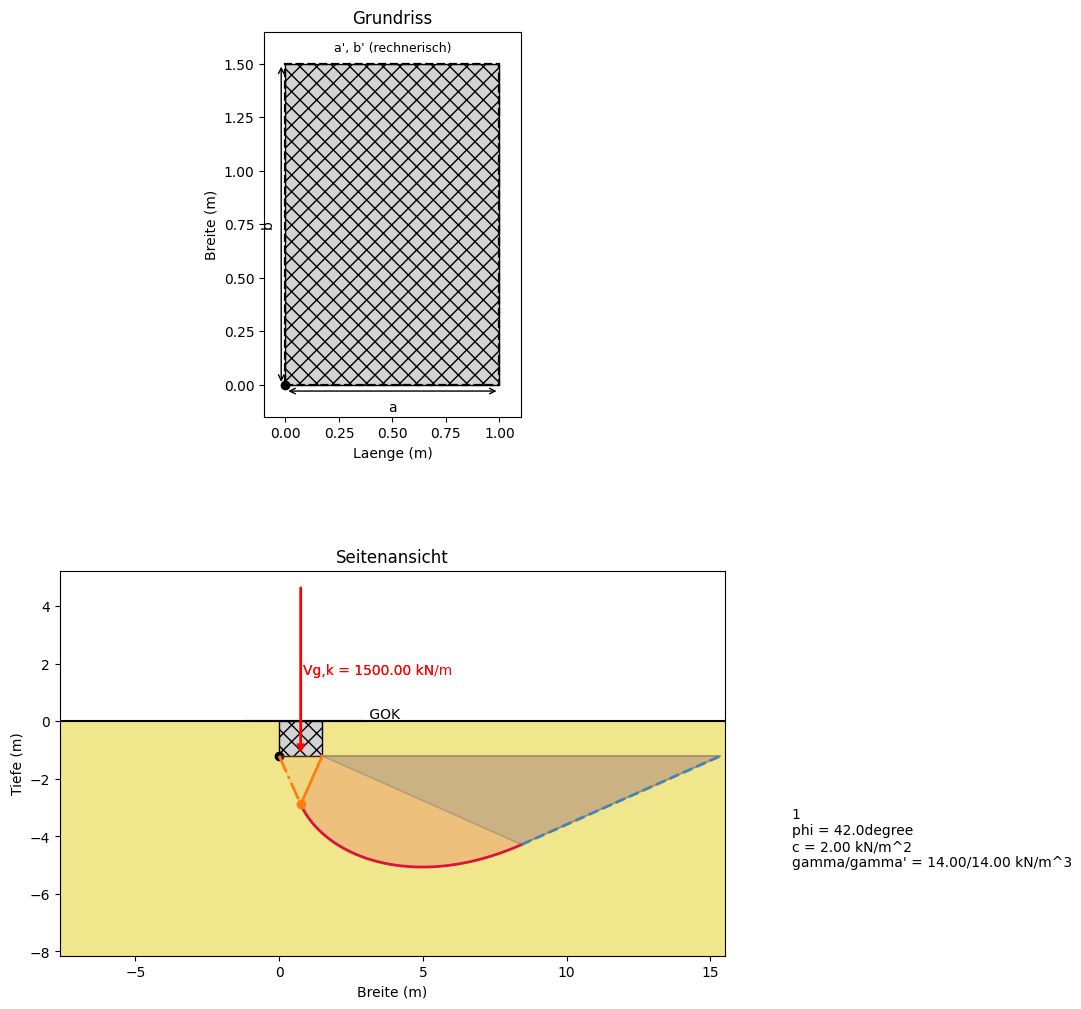


————————————————————————————————————————————————————————————————————
NACHWEIS GRUNDBRUCH (GEO-2)
————————————————————————————————————————————————————————————————————
  V_ed = 2025.00 kN/m   <   R_n,d = 3446.86 kN/m  ->  Sicherheit gegen Grundbruch ist nachgewiesen.
  • Ausnutzungsgrad ν = V_ed / R_n,d 0.59


In [ ]:
# Effektive Maße (für Plot-Innenrechteck; hier ohne Exzentrizität)
a_prime_plot, b_prime_plot, _, _ = effective_dimensions_from_eccentricity(ctx["a"], ctx["b"], 0.0, 0.0)

# δ-Ast zulässig?
use_delta_ast = (ctx["Hk"] and abs(ctx["Hk"])>1e-12 and ctx["phi_for_geometry"]>1e-9 
                 and abs(ctx["delta_deg"]) < ctx["phi_for_geometry"]-1e-9)
delta_for_geo = ctx["delta_deg"] if use_delta_ast else None

# Richtung des H-Pfeils im Grundriss
H_dir = "x"                      # oder "y"
ctx["H_dir"] = H_dir

plot_foundation(
    ctx["a"], ctx["b"], ctx["h"], ctx["d"],
    layers=ctx["layers"],
    z_gw=ctx["z_gw"],
    Vgk=ctx["Vgk"], Qk=ctx["Qk"],
    foundation_type=ctx["foundation_type"],
    phi_geom_override=ctx["phi_for_geometry"],
    Hk=ctx["Hk"],
    a_eff=a_prime_plot, b_eff=b_prime_plot,
    H_dir=H_dir,
    delta_deg_for_geo=delta_for_geo,
    alpha_deg_geo=0.0,
    beta_deg_geo=0.0
)
# === Zelle 15: Grundbruch berechnen & Kennwerte ausgeben ===
foundation_type_eff = "Streifen" if abs(ctx["a"] - 1.0) < 1e-6 else "Rechteck"
unitF = "kN/m" if foundation_type_eff == "Streifen" else "kN"

# Bestimmen des Bodensystems für die Berechnung (Scherparameter)
zsw_check = get_zsw(ctx["layers"])
if zsw_check is not None and zsw_check <= ctx["d"] + 1e-5:
    # Fall 1: Sohle 
    layers_for_bearing = ctx["layers"]
else:
    # Fall 2: Sohle > Schichtgrenze 
    layers_for_bearing = ctx["layers_eq"] if ctx["layers_eq"] is not None else ctx["layers"]
q0_real, _, _ = overburden_with_gw(ctx["layers"], ctx["d"], ctx["z_gw"], ctx["gamma_w"])

# ω für Lastneigungsbeiwerte
omega_for_m = 0.0 if ctx["H_dir"].lower().startswith("x") else 90.0

R_n_k, R_n_d, det = compute_Rn_bearing(
    a=ctx["a"], b=ctx["b"], d=ctx["d"],
    layers=layers_for_bearing,
    foundation_type=foundation_type_eff,
    gamma_R_v=ctx["gamma_R"],
    beta_deg=0.0, alpha_deg=0.0,
    z_gw=ctx["z_gw"], gamma_w=ctx["gamma_w"],
    Hk_char=ctx["Hk"], Vk_char=(ctx["Vgk"]+ctx["Qk"]),
    a_eff_for_shape=ctx["a"], b_eff_for_shape=ctx["b"],
    omega_deg=omega_for_m,
    delta_char_deg=ctx["delta_deg"],
    q0_override=q0_real 
)

# GEO-2
ok = ctx["V_ed"] < R_n_d
banner("NACHWEIS GRUNDBRUCH (GEO-2)")
print(f"  V_ed = {ctx['V_ed']:.2f} {unitF}   <   R_n,d = {R_n_d:.2f} {unitF}  ->  {'Sicherheit gegen Grundbruch ist nachgewiesen.' if ok else 'Sicherheit gegen Grundbruch NICHT nachweisbar.'}")
mu = ctx["V_ed"] / R_n_d if R_n_d > 0 else float('inf')
kv("Ausnutzungsgrad ν = V_ed / R_n,d", f"{mu:.2f}")


